# Task 1 — Diagnóstico, baselines e ARIMA/SARIMA

**Curso:** Séries Temporais · FGV EMAp · 2026/2

Três séries **diárias** da mesma loja Walmart (recorte M5 `CA_1`), já agregadas:

| Coluna | Série |
|---|---|
| `store_total` | total da loja |
| `FOODS` | categoria alimentos |
| `HOBBIES` | categoria hobbies |

O objetivo é prever os **28 dias** de 2016-03-28 a 2016-04-24 e comparar um
ARIMA/SARIMA contra quatro baselines simples.

## Roteiro

| Seção | Conteúdo |
|---|---|
| 0 | Setup — imports, constantes, configuração de gráficos |
| 1 | Os dados e o split temporal |
| 2 | Diagnóstico — série no tempo, outliers, sazonalidade, STL, estacionariedade, ACF/PACF |
| 3 | Os quatro baselines |
| 4 | Identificação da ordem — `D` pela força sazonal, `d` por KPSS iterativo, `p,q,P,Q` por grid de AICc |
| 5 | Previsão dos 28 dias |
| 6 | Métricas — MAE, RMSE e MASE na validação |
| 7 | Exportação de `previsoes_validacao.csv` e `metricas.csv` |
| 8 | Reprodução |

Rodar o notebook inteiro leva cerca de 6 minutos, quase todos no grid de AICc da
seção 4.

## 0. Setup

Imports, constantes do problema e configuração visual. Tudo que é fixo aparece
aqui uma única vez, para o resto do notebook não repetir número mágico.

Dois pontos sobre o ambiente:

- `torch` é instalado **fora** do `uv` (build ROCm para GPU AMD), então o import
  é protegido: o notebook roda inteiro sem ele. Veja o `README.md`.
- As figuras são salvas em `figuras/` além de aparecerem inline, para o
  diagnóstico ficar legível mesmo sem executar o notebook.

In [1]:
from __future__ import annotations

# --- BLAS em uma thread ----------------------------------------------------
# Duas camadas, porque uma só não cobre os dois modos de execução:
#
#   1. As variáveis de ambiente valem quando o processo é novo — `nbconvert`,
#      `python -m`, kernel recém-reiniciado. O OpenBLAS as lê ao carregar.
#   2. `threadpool_limits` age em tempo de execução, pela API da própria
#      biblioteca. É o que cobre o kernel quente do Jupyter ou do VS Code, em
#      que o numpy já foi importado e as variáveis chegam tarde demais.
#
# Importa para o resultado, não só para o tempo: com OpenBLAS multithread o
# L-BFGS percorre trajetórias diferentes entre execuções e o AICc deixa de ser
# reprodutível (medimos 18,1 e 27807,9 para o mesmo modelo). E sem a segunda
# camada, um "Run All" em kernel reaproveitado roda com 12 threads de BLAS por
# worker: ~84 threads disputando 12 núcleos, e o grid da seção 4 passa de
# 5 minutos para mais de 40.
import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import itertools
import multiprocessing as mp
import subprocess
import sys
import time
import warnings
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from threadpoolctl import threadpool_info, threadpool_limits
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning,
    EstimationWarning,
    InterpolationWarning,
)
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

# torch vem de uma instalação ROCm separada; o notebook não depende dele.
try:
    import torch

    TORCH_OK = True
except ImportError:
    TORCH_OK = False

# Segunda camada. A referência é mantida porque o limite vale enquanto o
# objeto viver; os processos filhos herdam o limite pelo fork.
_BLAS = threadpool_limits(limits=1)

ROOT = Path.cwd()
DATA = ROOT / "dados"
FIGS = ROOT / "figuras"
FIGS.mkdir(exist_ok=True)

SERIES = ("store_total", "FOODS", "HOBBIES")
M = 7  # período sazonal: a semana
H = 28  # horizonte da Task 1
VAL_START = pd.Timestamp("2016-03-28")
VAL_END = pd.Timestamp("2016-04-24")
TREINO_FIM = pd.Timestamp("2016-03-27")

# --- busca de ordem --------------------------------------------------------
P_MAX = Q_MAX = 3  # p, q ∈ 0..3
PS_MAX = QS_MAX = 2  # P, Q ∈ 0..2
MAXITER = 200  # o default (50) não converge nas ordens maiores e enviesa o AICc
K_BT = 12  # origens do backtest que decide o D do HOBBIES
N_JOBS = min(6, os.cpu_count() or 1)

_threads_blas = {i["internal_api"]: i["num_threads"] for i in threadpool_info()}
assert all(n == 1 for n in _threads_blas.values()), (
    f"BLAS com mais de uma thread: {_threads_blas}. O grid da seção 4 levaria dezenas "
    "de minutos. Reinicie o kernel e rode de novo."
)

print(f"pandas {pd.__version__} | numpy {np.__version__} | torch disponível: {TORCH_OK}")
print(f"BLAS {_threads_blas} | pool de {N_JOBS} processos | {os.cpu_count()} CPUs")

pandas 3.0.6 | numpy 2.5.3 | torch disponível: False
BLAS {} | pool de 6 processos | 10 CPUs


In [2]:
# --- paleta e estilo -------------------------------------------------------
# Cores categóricas validadas para daltonismo (ΔE CVD ≥ 9.2 entre todos os pares).
SURFACE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
LINHA = "#d8d7d2"
CORES = {"store_total": "#2a78d6", "FOODS": "#eb6834", "HOBBIES": "#1baf7a"}
DESTAQUE = "#e34948"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
    "figure.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": LINHA,
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.titlelocation": "left",
    "axes.labelsize": 9,
    "axes.labelcolor": TINTA_2,
    "text.color": TINTA,
    "xtick.color": TINTA_2,
    "ytick.color": TINTA_2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})


def painel(n=3, altura=2.4, largura=11.0, ncols=1, sharex=True, sharey=False):
    """Uma figura com um painel por série (small multiples)."""
    fig, axes = plt.subplots(
        n, ncols, figsize=(largura, altura * n), sharex=sharex, sharey=sharey
    )
    return fig, np.atleast_1d(axes).ravel()


def salvar(fig, nome: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGS / nome)
    print(f"  → figuras/{nome}")


MESES_PT = ["jan", "fev", "mar", "abr", "mai", "jun",
            "jul", "ago", "set", "out", "nov", "dez"]


def eixo_mes(ax) -> None:
    """Rótulos de mês em português, para o gráfico não misturar idiomas."""
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f"{MESES_PT[mdates.num2date(x).month - 1]}/{mdates.num2date(x):%y}"
        )
    )

## 1. Os dados e o split temporal

Três arquivos em `data/`:

| Arquivo | Período | Tem `y`? |
|---|---|---|
| `treino.csv` | 2011-01-29 a 2016-03-27 | sim |
| `validacao.csv` | 2016-03-28 a 2016-04-24 | sim — **é o horizonte desta Task** |
| `holdout_datas.csv` | 2016-04-25 a 2016-05-22 | **não**, só as datas |

O `y` do holdout não faz parte desta entrega: ele é o score cego da A2. Por isso
ele aparece aqui só como lista de datas que **não podem** receber previsão.

In [3]:
train = pd.read_csv(DATA / "treino.csv", parse_dates=["date"]).sort_values("date")
val = pd.read_csv(DATA / "validacao.csv", parse_dates=["date"]).sort_values("date")
holdout = pd.read_csv(DATA / "holdout_datas.csv", parse_dates=["date"]).sort_values("date")

train = train.set_index("date").asfreq("D")
val = val.set_index("date").asfreq("D")

print(f"treino    {train.index.min().date()} → {train.index.max().date()}  ({len(train)} dias)")
print(f"validação {val.index.min().date()} → {val.index.max().date()}  ({len(val)} dias)")
print(f"holdout   {holdout['date'].min().date()} → {holdout['date'].max().date()}  ({len(holdout)} datas, sem y)")

treino    2011-01-29 → 2016-03-27  (1885 dias)
validação 2016-03-28 → 2016-04-24  (28 dias)
holdout   2016-04-25 → 2016-05-22  (28 datas, sem y)


### Integridade do split

Checagens que falham alto se algo estiver fora do lugar — é mais barato quebrar
aqui do que descobrir vazamento no fim.

In [4]:
assert train.index.max() == TREINO_FIM, "treino não termina em 2016-03-27"
assert val.index.min() == VAL_START and val.index.max() == VAL_END, "validação fora do horizonte"
assert len(val) == 28, "validação não tem 28 dias"
assert not train.index.has_duplicates and not val.index.has_duplicates
assert train.index.to_series().diff().dropna().eq(pd.Timedelta(days=1)).all(), "buraco de data no treino"
assert train.notna().all().all(), "NaN no treino"
assert train.index.max() < val.index.min() < pd.Timestamp(holdout["date"].min()), "ordem dos blocos errada"
assert set(SERIES) == set(train.columns) == set(val.columns)

print("split íntegro: treino < validação < holdout, sem buracos e sem NaN")

split íntegro: treino < validação < holdout, sem buracos e sem NaN


In [5]:
resumo = pd.DataFrame({
    "n": train.count(),
    "média": train.mean().round(1),
    "desvio": train.std().round(1),
    "mín": train.min(),
    "máx": train.max(),
    "mediana": train.median(),
}).loc[list(SERIES)]
resumo

,n,média,desvio,mín,máx,mediana
store_total,1885,4016.1,990.0,0,6948,3899.0
FOODS,1885,2809.6,701.2,0,5016,2710.0
HOBBIES,1885,457.1,123.6,0,953,458.0


### A regra anti-vazamento

> Se a informação não existiria em **2016-03-27**, ela não entra no treino.

Na prática, três consequências que valem **2,5 pontos** do critério de split:

1. Todo modelo é ajustado **só** com `treino.csv`. A validação nunca é usada no `fit`.
2. `previsoes_validacao.csv` só pode conter datas entre 2016-03-28 e 2016-04-24.
3. Nenhuma data do holdout aparece na entrega.

Como as séries são temporais, não existe embaralhar linhas: a ordem cronológica
é a informação.

## 2. Diagnóstico

Objetivo desta seção: entender **tendência**, **sazonalidade semanal** e
**outliers** antes de escolher qualquer modelo. É daqui que sai a ordem do
SARIMA.

### 2.1 A série no tempo

Primeiro a visão completa, 2011 a 2016. Um painel por série porque as escalas
são muito diferentes (`store_total` roda na casa dos milhares, `HOBBIES` nas
centenas) — sobrepor as três num eixo só esconderia a menor.

  → figuras/01_series_completas.png


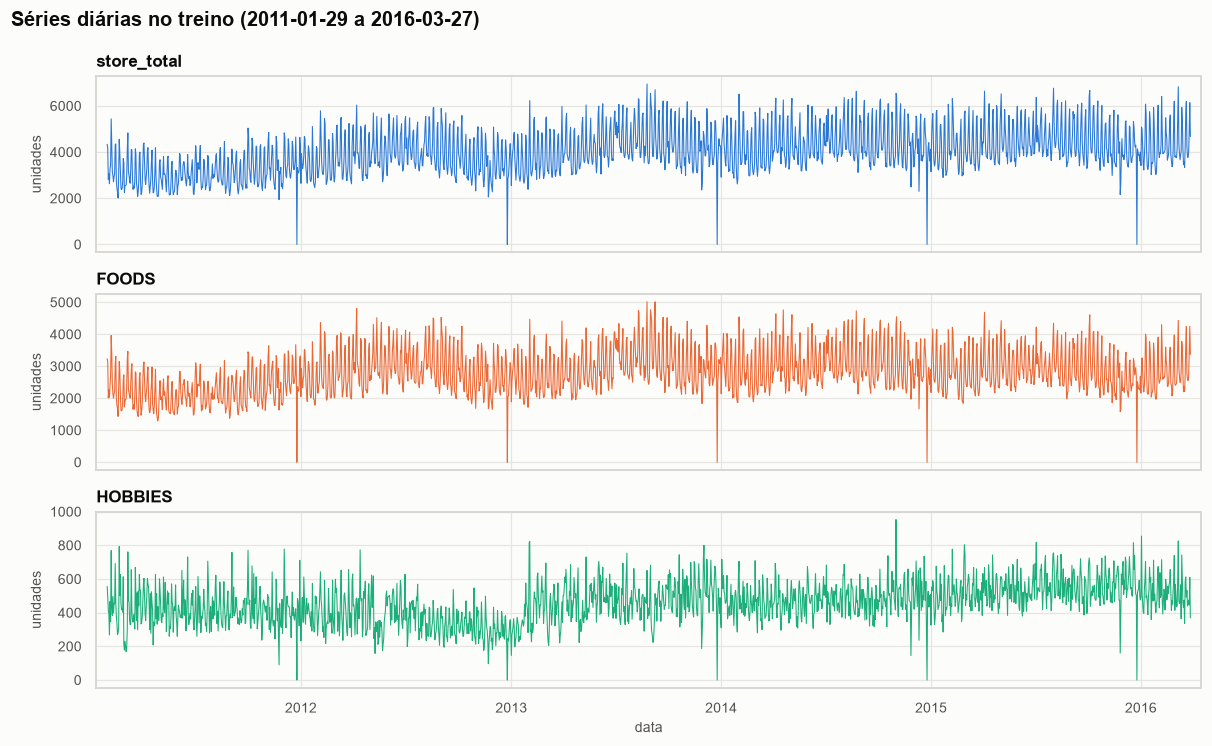

In [6]:
fig, axes = painel(3, altura=2.3)
for ax, s in zip(axes, SERIES):
    ax.plot(train.index, train[s], color=CORES[s], lw=0.7)
    ax.set_title(s)
    ax.set_ylabel("unidades")
    ax.margins(x=0.01)
axes[-1].set_xlabel("data")
fig.suptitle("Séries diárias no treino (2011-01-29 a 2016-03-27)", x=0.0, ha="left",
             fontsize=13, fontweight="bold")
salvar(fig, "01_series_completas.png")
plt.show()

Agora o zoom nos últimos 120 dias do treino, com o início da validação marcado.
É a janela que o modelo realmente "vê" ao prever, e onde a estrutura semanal
fica visível a olho nu.

  → figuras/02_series_zoom.png


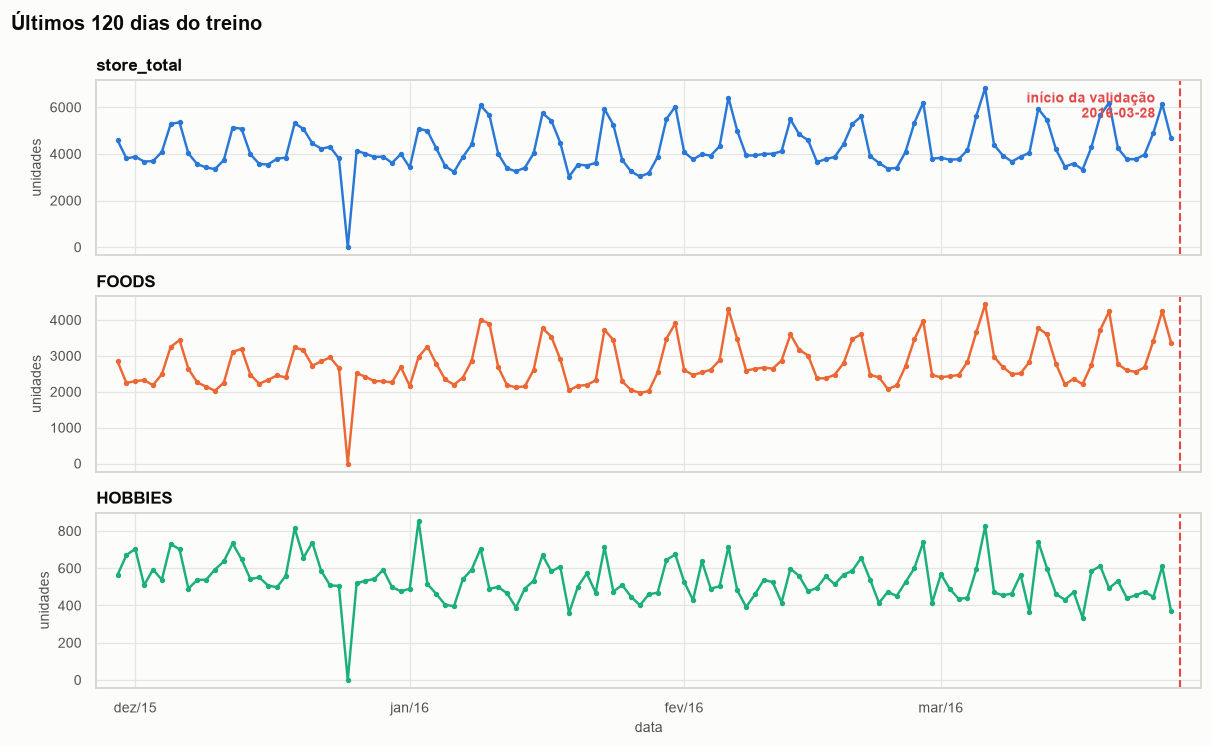

In [7]:
jan_ini = TREINO_FIM - pd.Timedelta(days=119)
fig, axes = painel(3, altura=2.3)
for ax, s in zip(axes, SERIES):
    janela = train.loc[jan_ini:, s]
    ax.plot(janela.index, janela, color=CORES[s], lw=1.6, marker="o", ms=2.5)
    ax.axvline(VAL_START, color=DESTAQUE, lw=1.4, ls="--")
    ax.set_title(s)
    ax.set_ylabel("unidades")
    ax.margins(x=0.02)
axes[0].annotate("início da validação\n2016-03-28", xy=(VAL_START, 0.94),
                 xycoords=("data", "axes fraction"), xytext=(-16, 0),
                 textcoords="offset points", ha="right", va="top",
                 fontsize=9, color=DESTAQUE, fontweight="bold")
eixo_mes(axes[-1])
axes[-1].set_xlabel("data")
fig.suptitle("Últimos 120 dias do treino", x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "02_series_zoom.png")
plt.show()

### 2.2 Outliers de calendário

O enunciado avisa que existem zeros de calendário. Vamos localizá-los.

In [8]:
zeros = train[(train[list(SERIES)] == 0).any(axis=1)]
print(f"{len(zeros)} dias com zero em alguma série:\n")
zeros.assign(dia=zeros.index.day_name())

5 dias com zero em alguma série:



,store_total,FOODS,HOBBIES,dia
date,,,,
2011-12-25,0,0,0,Sunday
2012-12-25,0,0,0,Tuesday
2013-12-25,0,0,0,Wednesday
2014-12-25,0,0,0,Thursday
2015-12-25,0,0,0,Friday


São exatamente **5 dias**, todos 25 de dezembro, e as três séries zeram juntas:
a loja fecha no Natal. Não é ruído de medição, é fechamento.

Mas o zero não está sozinho — a semana inteira de festas é um vale. Comparando
`store_total` (média geral ≈ 4027) nos dias ao redor:

In [9]:
anos = range(2011, 2016)
vizinhanca = pd.DataFrame(
    {
        rotulo: [train["store_total"].get(pd.Timestamp(f"{a + salto}-{mmdd}"), np.nan) for a in anos]
        for rotulo, mmdd, salto in [
            ("18/12", "12-18", 0), ("24/12", "12-24", 0), ("25/12", "12-25", 0),
            ("26/12", "12-26", 0), ("01/01", "01-01", 1),
        ]
    },
    index=[f"{a}" for a in anos],
).astype("Int64")
vizinhanca.index.name = "ano"
print(f"média geral de store_total (sem os zeros): {train['store_total'][train['store_total'] > 0].mean():.0f}\n")
vizinhanca

média geral de store_total (sem os zeros): 4027



,18/12,24/12,25/12,26/12,01/01
ano,,,,,
2011,4253,3454,0,3335,2648
2012,3277,3370,0,2862,2552
2013,3453,3458,0,3570,2913
2014,3836,3487,0,3593,3150
2015,3843,3803,0,4137,3418


  → figuras/03_zeros_natal.png


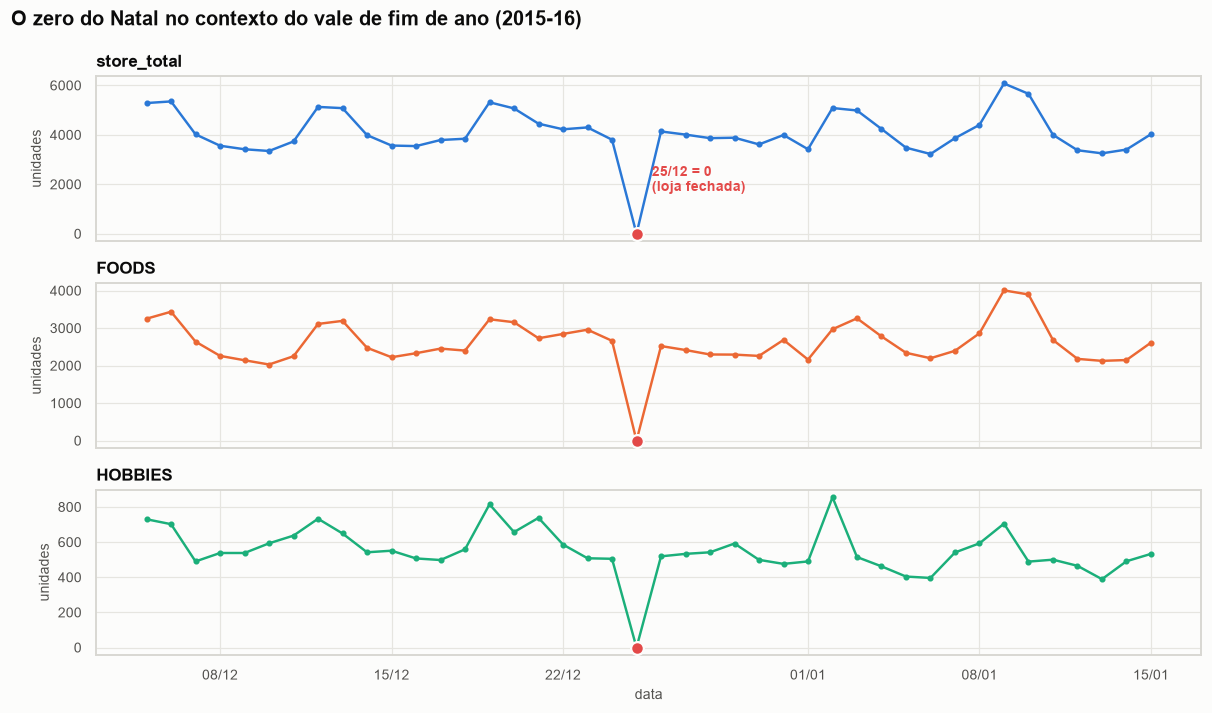

In [10]:
fig, axes = painel(3, altura=2.2)
ini, fim = pd.Timestamp("2015-12-05"), pd.Timestamp("2016-01-15")
for ax, s in zip(axes, SERIES):
    janela = train.loc[ini:fim, s]
    ax.plot(janela.index, janela, color=CORES[s], lw=1.6, marker="o", ms=3)
    natal = pd.Timestamp("2015-12-25")
    ax.scatter([natal], [train.loc[natal, s]], s=70, color=DESTAQUE, zorder=5,
               edgecolor=SURFACE, linewidth=1.5)
    ax.set_title(s)
    ax.set_ylabel("unidades")
axes[0].annotate("25/12 = 0\n(loja fechada)", xy=(pd.Timestamp("2015-12-25"), 0),
                 xytext=(10, 28), textcoords="offset points", fontsize=9,
                 color=DESTAQUE, fontweight="bold")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[-1].set_xlabel("data")
fig.suptitle("O zero do Natal no contexto do vale de fim de ano (2015-16)",
             x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "03_zeros_natal.png")
plt.show()

#### Decisão: interpolar os zeros, mas só para o SARIMA

O zero está a cerca de **4 desvios-padrão** abaixo da média. Na verossimilhança
gaussiana do SARIMA ele entra ao quadrado, então um único ponto desses pesa como
~17 pontos normais. Com diferenciação regular e sazonal, cada zero vira um par de
choques (queda + repique). Isso tem três efeitos ruins:

1. **Atenua o ACF/PACF** — o outlier infla a variância no denominador da
   autocorrelação, puxando todos os lags em direção a zero. São justamente esses
   gráficos que usamos para escolher a ordem.
2. **Infla a variância dos resíduos**, alargando os intervalos de previsão.
3. **Distorce o AIC**, que pode premiar a ordem que melhor absorve o Natal em vez
   da que melhor modela a semana.

Então criamos uma cópia interpolada para a identificação e o ajuste do SARIMA.
**Baselines e métricas continuam no dado cru** — a escala do MASE, em particular,
é obrigatoriamente calculada do CSV cru, para bater com a correção.

**Por que interpolação linear e não a média de ±7 dias?** Porque `25/12 + 7 = 01/01`,
que também é dia atípico (tabela acima: 2552 a 3418, contra média de 4027). A
interpolação linear usa 24/12 e 26/12, ambos dentro da mesma semana de festas —
vizinhança mais representativa. Repare na tabela abaixo que os valores
interpolados ficam na faixa dos 3100-3900, ou seja, **preservam o vale** de fim
de ano e removem só o zero artificial.

In [11]:
train_fit = train.copy()
train_fit[list(SERIES)] = train_fit[list(SERIES)].mask(train_fit[list(SERIES)] == 0).interpolate()

comparacao = pd.concat(
    [train.loc[zeros.index, list(SERIES)].add_suffix(" cru"),
     train_fit.loc[zeros.index, list(SERIES)].round(0).astype(int).add_suffix(" interp")],
    axis=1,
)[[f"{s} {k}" for s in SERIES for k in ("cru", "interp")]]
print("train      = dado cru      → baselines, métricas, escala do MASE")
print("train_fit  = interpolado   → ACF/PACF e ajuste do SARIMA\n")
comparacao

train      = dado cru      → baselines, métricas, escala do MASE
train_fit  = interpolado   → ACF/PACF e ajuste do SARIMA



,store_total cru,store_total interp,FOODS cru,FOODS interp,HOBBIES cru,HOBBIES interp
date,,,,,,
2011-12-25,0,3394,0,2559,0,408
2012-12-25,0,3116,0,2388,0,222
2013-12-25,0,3514,0,2552,0,409
2014-12-25,0,3540,0,2488,0,384
2015-12-25,0,3970,0,2592,0,512


In [12]:
# Efeito da interpolação na autocorrelação — é o que motiva a decisão.
efeito = pd.DataFrame(
    {
        s: {
            "ACF(1) cru": acf(train[s], nlags=1)[1],
            "ACF(1) interp": acf(train_fit[s], nlags=1)[1],
            "ACF(7) cru": acf(train[s], nlags=7)[7],
            "ACF(7) interp": acf(train_fit[s], nlags=7)[7],
        }
        for s in SERIES
    }
).round(4)
efeito

,store_total,FOODS,HOBBIES
ACF(1) cru,0.6172,0.6102,0.4845
ACF(1) interp,0.6350,0.6288,0.4949
ACF(7) cru,0.8124,0.7790,0.5247
ACF(7) interp,0.8355,0.8007,0.5336


### 2.3 Sazonalidade semanal

O enunciado já aponta `m = 7`. Vamos confirmar e medir o tamanho do efeito.

  → figuras/04_sazonalidade_semanal.png


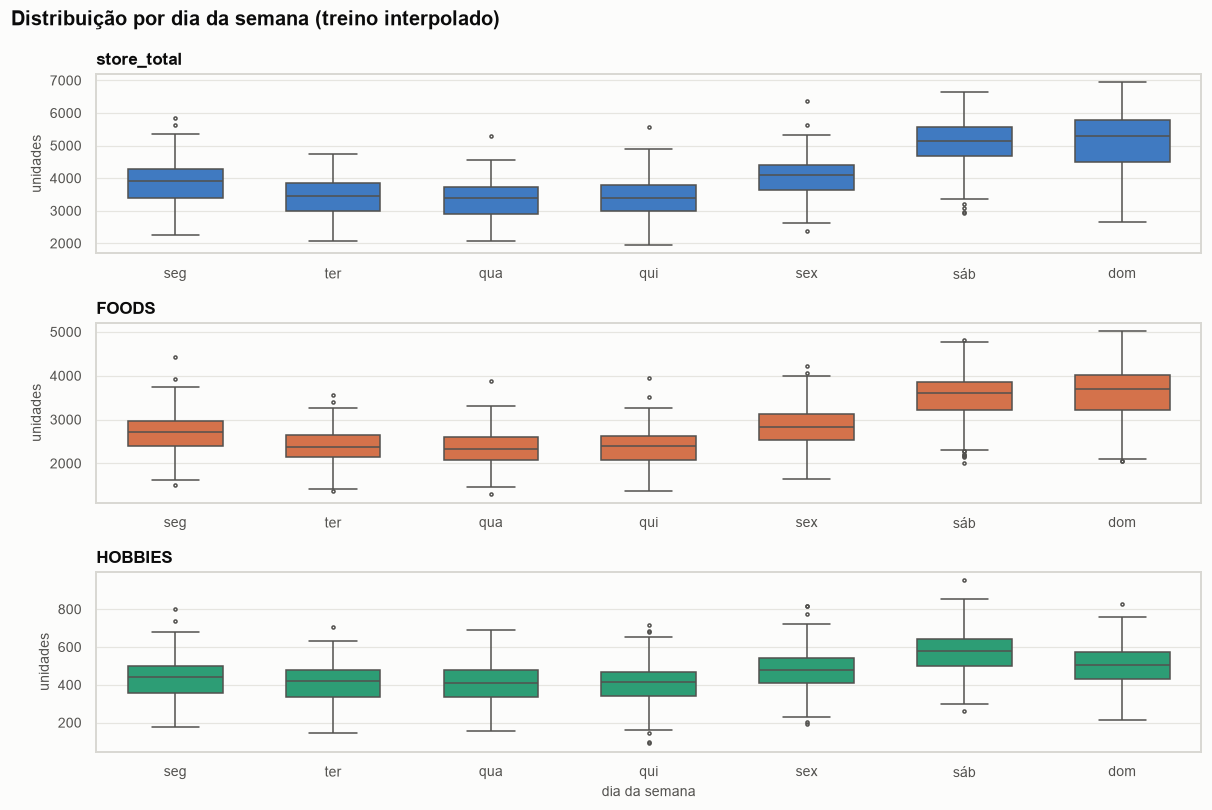

In [13]:
DIAS = ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"]
longo = train_fit.copy()
longo["dia"] = pd.Categorical(
    [DIAS[d] for d in longo.index.dayofweek], categories=DIAS, ordered=True
)

fig, axes = painel(3, altura=2.5, sharex=False)
for ax, s in zip(axes, SERIES):
    sns.boxplot(data=longo, x="dia", y=s, ax=ax, color=CORES[s], width=0.6,
                linewidth=1.0, fliersize=2, linecolor=TINTA_2)
    ax.set_title(s)
    ax.set_xlabel("")
    ax.set_ylabel("unidades")
axes[-1].set_xlabel("dia da semana")
fig.suptitle("Distribuição por dia da semana (treino interpolado)", x=0.0, ha="left",
             fontsize=13, fontweight="bold")
salvar(fig, "04_sazonalidade_semanal.png")
plt.show()

In [14]:
perfil = longo.groupby("dia", observed=True)[list(SERIES)].mean()
indice = (perfil / perfil.mean() * 100).round(1)
indice.columns = [f"{c} (índice)" for c in indice.columns]
pd.concat([perfil.round(0).astype(int), indice], axis=1)

,store_total,FOODS,HOBBIES,store_total (índice),FOODS (índice),HOBBIES (índice)
dia,,,,,,
seg,3846,2690,431,95.6,95.5,94.2
ter,3417,2380,410,84.9,84.5,89.5
qua,3329,2322,406,82.7,82.5,88.7
qui,3367,2351,407,83.7,83.5,88.9
sex,4030,2826,474,100.1,100.4,103.4
sáb,5055,3522,571,125.6,125.1,124.8
dom,5127,3617,506,127.4,128.5,110.5


O índice é a média do dia dividida pela média geral, em base 100. Quanto mais
longe de 100, mais forte a sazonalidade semanal.

### 2.4 Decomposição STL

A STL separa a série em tendência + componente sazonal + resto. Serve para dois
fins aqui: visualizar os três ingredientes separados, e calcular a **força
sazonal**

$$F_s = \max\left(0,\; 1 - \frac{\operatorname{Var}(\text{resto})}{\operatorname{Var}(\text{resto} + \text{sazonal})}\right)$$

que é o critério de Wang-Smyth-Hyndman: $F_s > 0{,}64$ indica sazonalidade forte
o bastante para justificar **uma** diferenciação sazonal, ou seja $D = 1$.
A força de tendência $F_t$ é análoga, trocando sazonal por tendência.

  → figuras/05_stl.png


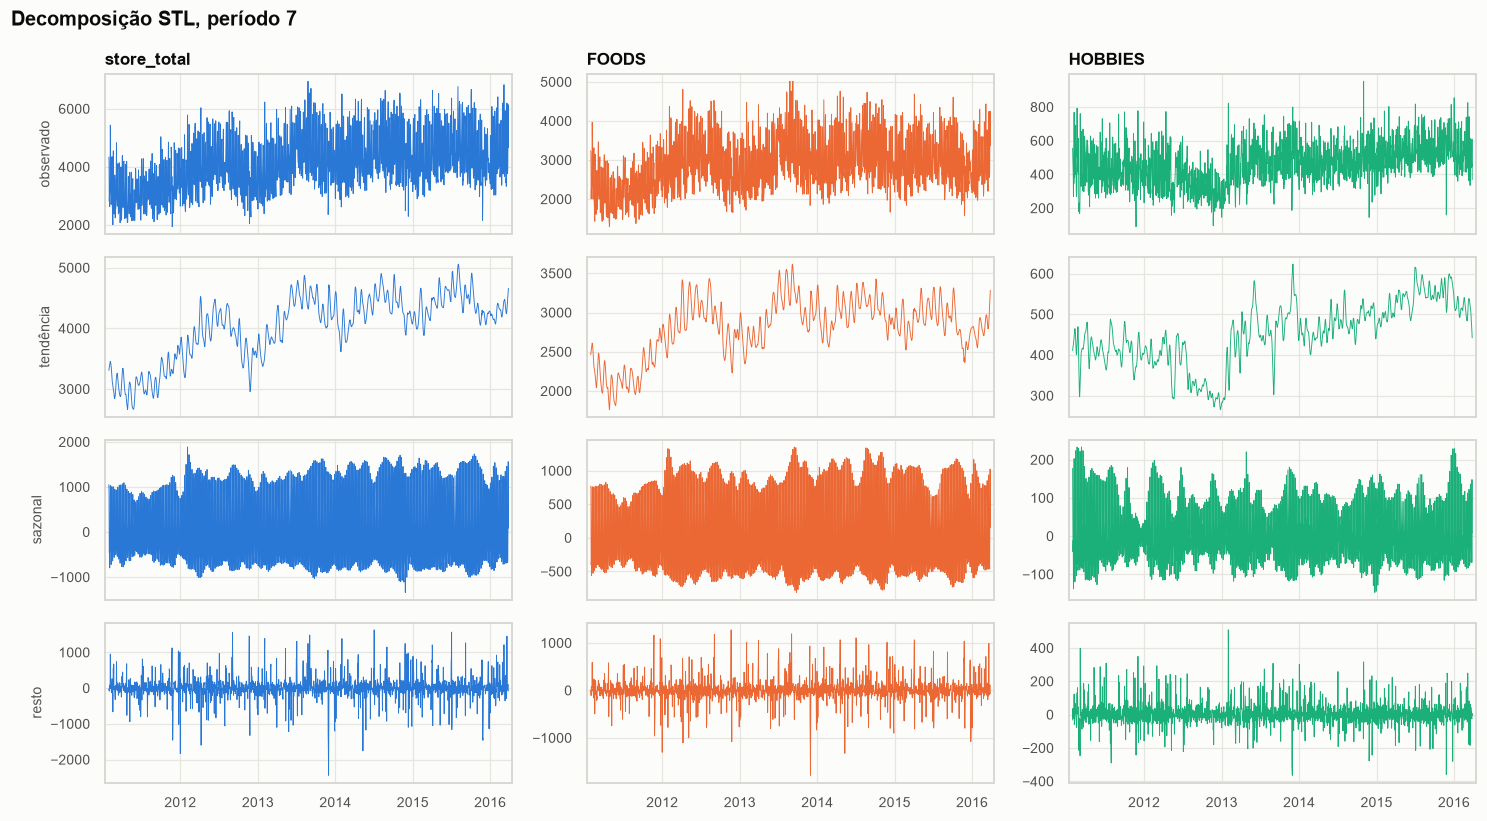

In [15]:
stl = {s: STL(train_fit[s], period=M, robust=True).fit() for s in SERIES}

fig, axes = painel(4, altura=1.9, ncols=3, largura=13.5, sharex=True)
axes = axes.reshape(4, 3)
componentes = ["observado", "tendência", "sazonal", "resto"]
for j, s in enumerate(SERIES):
    r = stl[s]
    for i, (nome, serie) in enumerate(
        zip(componentes, [train_fit[s], r.trend, r.seasonal, r.resid])
    ):
        ax = axes[i, j]
        ax.plot(serie.index, serie, color=CORES[s], lw=0.6)
        ax.margins(x=0.01)
        if i == 0:
            ax.set_title(s)
        if j == 0:
            ax.set_ylabel(nome)
fig.suptitle("Decomposição STL, período 7", x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "05_stl.png")
plt.show()

In [16]:
def forcas(res) -> dict[str, float]:
    resto, saz, tend = res.resid, res.seasonal, res.trend
    return {
        "F_sazonal": max(0.0, 1 - resto.var() / (resto + saz).var()),
        "F_tendência": max(0.0, 1 - resto.var() / (resto + tend).var()),
    }


tabela_forcas = pd.DataFrame({s: forcas(stl[s]) for s in SERIES}).T.round(3)
tabela_forcas["sugere D"] = (tabela_forcas["F_sazonal"] > 0.64).map({True: "1", False: "0"})
tabela_forcas

,F_sazonal,F_tendência,sugere D
store_total,0.837,0.734,1
FOODS,0.825,0.706,1
HOBBIES,0.465,0.526,0


### 2.5 Estacionariedade

Dois testes com hipóteses nulas **opostas**, por isso vale rodar os dois:

| Teste | H₀ | Rejeitar (p baixo) significa |
|---|---|---|
| **KPSS** | a série é estacionária | **não** é estacionária → diferenciar |
| **ADF** | a série tem raiz unitária | **é** estacionária → não diferenciar |

Rodamos em três versões de cada série: em nível, após diferenciação sazonal
$(1-B^7)$, e após sazonal + regular $(1-B)(1-B^7)$.

In [17]:
def kpss_teste(x) -> tuple[float, float, int]:
    """KPSS em nível. `result_object=True` evita o FutureWarning do statsmodels 0.15."""
    with warnings.catch_warnings():
        # o p-valor satura em 0,01 e 0,10, limites da tabela do teste
        warnings.simplefilter("ignore", InterpolationWarning)
        r = kpss(np.asarray(x, dtype=float), regression="c", nlags="auto", result_object=True)
    return float(r.statistic), float(r.pvalue), int(r.lags)


def adf_teste(x) -> tuple[float, float]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        r = adfuller(np.asarray(x, dtype=float), autolag="AIC", result_object=True)
    return float(r.statistic), float(r.pvalue)


def testes(x: pd.Series) -> dict[str, float]:
    x = x.dropna()
    kp_stat, kp_p, _ = kpss_teste(x)
    ad_stat, ad_p = adf_teste(x)
    return {"KPSS stat": kp_stat, "KPSS p": kp_p, "ADF stat": ad_stat, "ADF p": ad_p}


versoes = {
    "nível": lambda x: x,
    "diff sazonal (1-B⁷)": lambda x: x.diff(M),
    "sazonal + regular": lambda x: x.diff(M).diff(1),
}

estac = pd.DataFrame(
    {(s, nome): testes(f(train_fit[s])) for s in SERIES for nome, f in versoes.items()}
).T.round(4)
estac.index.names = ["série", "versão"]
estac["KPSS rejeita H₀"] = np.where(estac["KPSS p"] < 0.05, "sim → diferenciar", "não")
estac["ADF rejeita H₀"] = np.where(estac["ADF p"] < 0.05, "sim → estacionária", "não")
estac

KPSS stat  KPSS p  ADF stat   ADF p  \
série       versão                                                     
store_total nível                  11.8135    0.01   -2.0835  0.2512   
            diff sazonal (1-B⁷)     0.0093    0.10  -17.7269  0.0000   
            sazonal + regular       0.0264    0.10  -19.0924  0.0000   
FOODS       nível                   8.5439    0.01   -2.3898  0.1446   
            diff sazonal (1-B⁷)     0.0103    0.10  -15.1066  0.0000   
            sazonal + regular       0.0224    0.10  -20.0422  0.0000   
HOBBIES     nível                   5.0515    0.01   -2.9794  0.0369   
            diff sazonal (1-B⁷)     0.0075    0.10  -14.5118  0.0000   
            sazonal + regular       0.0202    0.10  -16.8198  0.0000   

                                   KPSS rejeita H₀      ADF rejeita H₀  
série       versão                                                      
store_total nível                sim → diferenciar                 não  
            diff sazonal (1-B⁷)                não  sim → estacionária  
            sazonal + regular                  não  sim → estacionária  
FOODS       nível                sim → diferenciar                 não  
            diff sazonal (1-B⁷)                não  sim → estacionária  
            sazonal + regular                  não  sim → estacionária  
HOBBIES     nível                sim → diferenciar  sim → estacionária  
            diff sazonal (1-B⁷)                não  sim → estacionária  
            sazonal + regular                  não  sim → estacionária

**Como ler**: o `d` sai de um KPSS iterativo — testa, se rejeitar diferencia e
testa de novo, até não rejeitar (máximo 2). O `D` **não** sai do KPSS: ele testa
estacionariedade em nível, e sazonalidade determinística forte faz o teste
rejeitar mesmo sem raiz unitária sazonal. Por isso o `D` vem da força sazonal da
seção 2.4, confirmada pelos correlogramas abaixo.

Nota sobre o `p` do KPSS: a tabela do teste vai de 0,01 a 0,10, então valores nos
extremos aparecem truncados (`0.01` significa "≤ 0,01").

### 2.6 ACF e PACF

Os correlogramas são a ferramenta de identificação da ordem. As linhas verticais
cinzas marcam os múltiplos de 7, e a faixa sombreada é a banda de confiança de
95% ($\pm 1{,}96/\sqrt{n}$): barras dentro da faixa são indistinguíveis de ruído.
Com $n \approx 1878$ a banda é estreita, $\pm 0{,}045$.

O **lag 0 é omitido** — ele vale 1 por definição e só comprimiria a escala dos
lags que interessam.

In [18]:
def correlogramas(dados: pd.DataFrame, transform, titulo: str, nome_arquivo: str, lags: int = 42):
    fig, axes = painel(3, altura=2.1, ncols=2, largura=13.0, sharex=True)
    axes = axes.reshape(3, 2)
    for i, s in enumerate(SERIES):
        x = transform(dados[s]).dropna()
        conf = 1.96 / np.sqrt(len(x))
        for j, (func, rotulo) in enumerate([(acf, "ACF"), (pacf, "PACF")]):
            vals = func(x, nlags=lags) if rotulo == "ACF" else func(x, nlags=lags, method="ywm")
            vals = vals[1:]  # lag 0 é sempre 1; omitido para não achatar a escala
            k = np.arange(1, len(vals) + 1)
            ax = axes[i, j]
            for L in range(M, lags + 1, M):
                ax.axvline(L, color=LINHA, lw=0.9, zorder=0)
            ax.axhspan(-conf, conf, color=TINTA_2, alpha=0.18, lw=0, zorder=1)
            ax.vlines(k, 0, vals, color=CORES[s], lw=1.8, zorder=3)
            ax.axhline(0, color=TINTA_2, lw=0.9, zorder=2)
            ax.set_title(f"{s} — {rotulo}")
            limite = max(0.25, np.abs(vals).max() * 1.15)
            ax.set_ylim(-limite, limite)
            ax.set_xlim(0.2, lags + 0.8)
            ax.set_xticks(range(0, lags + 1, M))
            if i == 2:
                ax.set_xlabel("lag (dias)")
    fig.suptitle(titulo, x=0.0, ha="left", fontsize=13, fontweight="bold")
    salvar(fig, nome_arquivo)
    plt.show()

  → figuras/06_acf_pacf_nivel.png


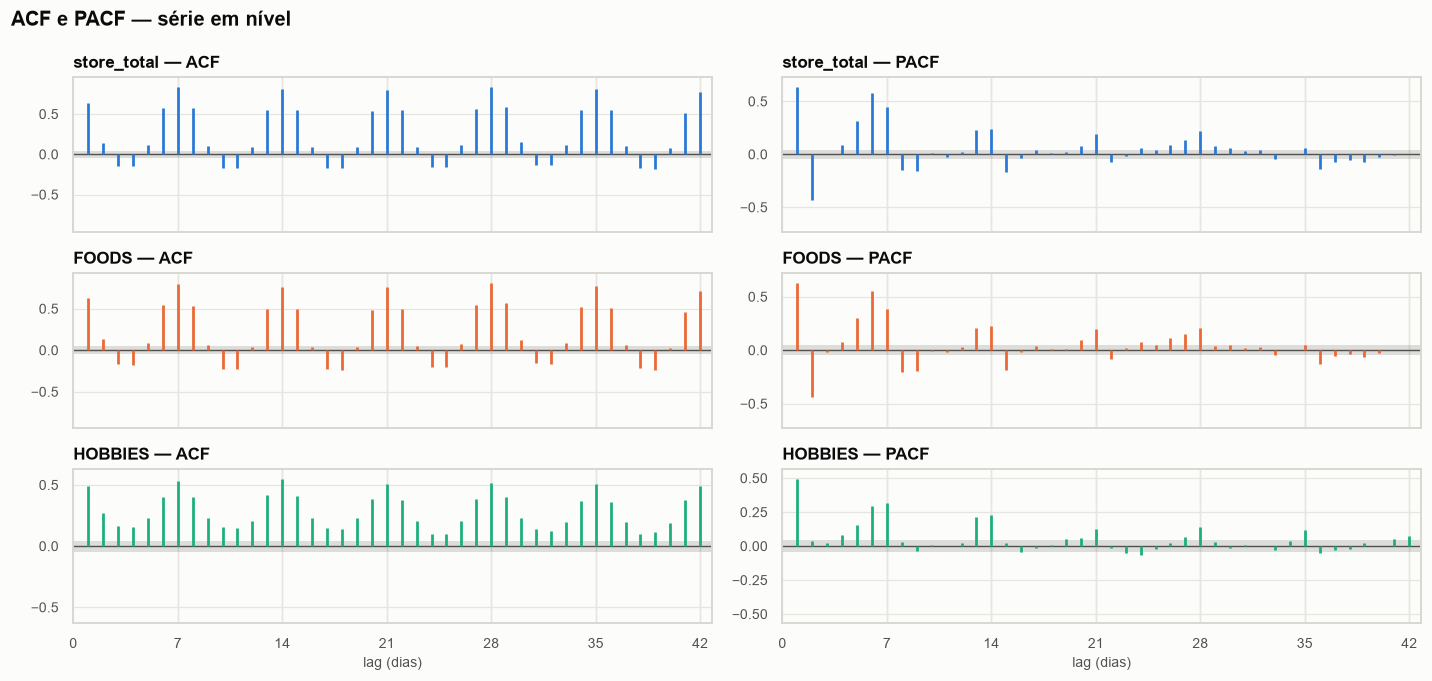

In [19]:
correlogramas(train_fit, lambda x: x,
              "ACF e PACF — série em nível", "06_acf_pacf_nivel.png")

#### O mesmo correlograma no treino cru

Os correlogramas desta seção usam `train_fit`, a cópia com os zeros de 25/12
interpolados, porque é ela que alimenta a identificação da ordem (seção 2.2). O
enunciado pede ACF e PACF **no treino**, então aqui está o mesmo gráfico sobre a
série crua, sem nenhum tratamento.

Os dois são visualmente indistinguíveis. A interpolação move a ACF do lag 7 de
**0,812 para 0,836** em `store_total` e de **0,525 para 0,534** em `HOBBIES` (tabela
da seção 2.2): efeito real, suficiente para justificar o tratamento no ajuste do
SARIMA, pequeno demais para mudar a leitura da ordem.

  → figuras/06b_acf_pacf_nivel_cru.png


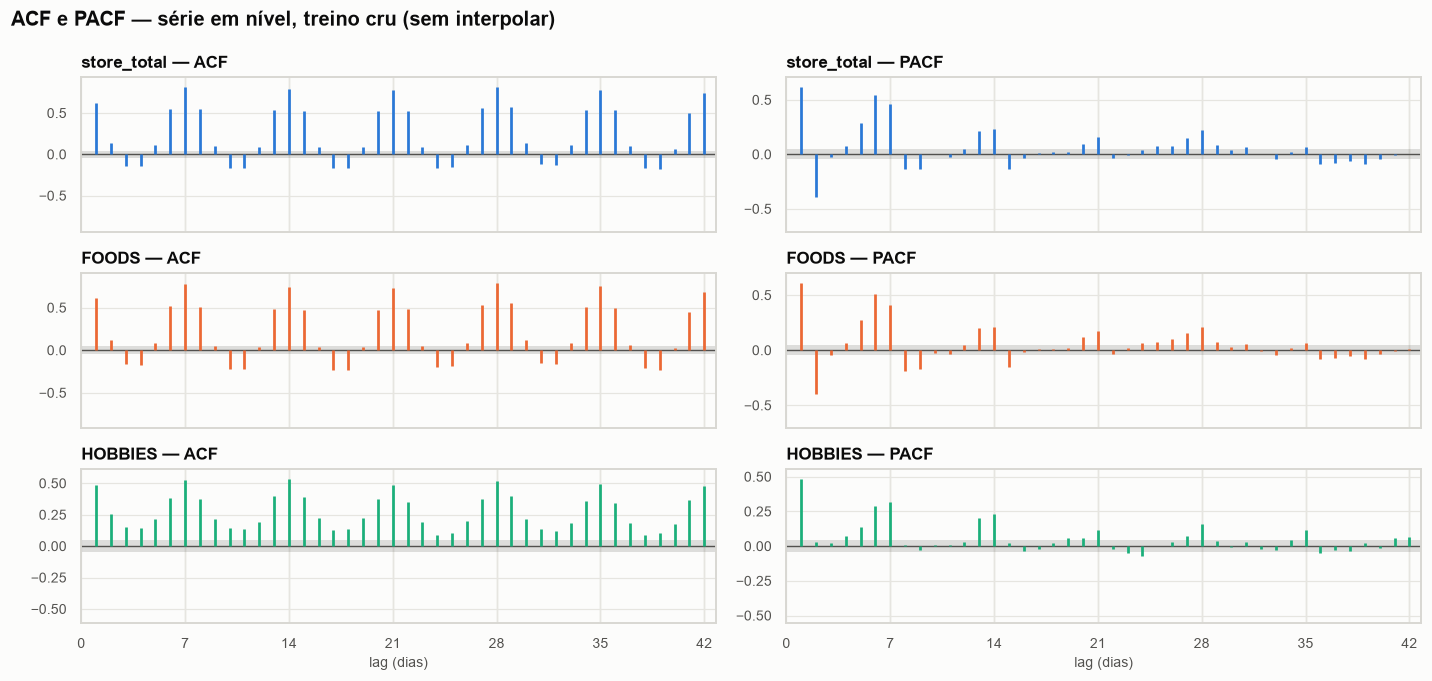

In [20]:
correlogramas(train, lambda x: x,
              "ACF e PACF — série em nível, treino cru (sem interpolar)",
              "06b_acf_pacf_nivel_cru.png")

/var/folders/b_/1_lgxzw979xg1l34kqfnjgfw0000gn/T/ipykernel_41340/1383855348.py:44: UserWarning: Glyph 8311 (\N{SUPERSCRIPT SEVEN}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/b_/1_lgxzw979xg1l34kqfnjgfw0000gn/T/ipykernel_41340/1383855348.py:45: UserWarning: Glyph 8311 (\N{SUPERSCRIPT SEVEN}) missing from font(s) Arial.
  fig.savefig(FIGS / nome)
/Users/sodre/Library/CloudStorage/OneDrive-FundacaoGetulioVargas-FGV/FGV - CD/6 PERÍODO/Séries Temporais/time-series-2026-2/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8311 (\N{SUPERSCRIPT SEVEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


  → figuras/07_acf_pacf_d7.png


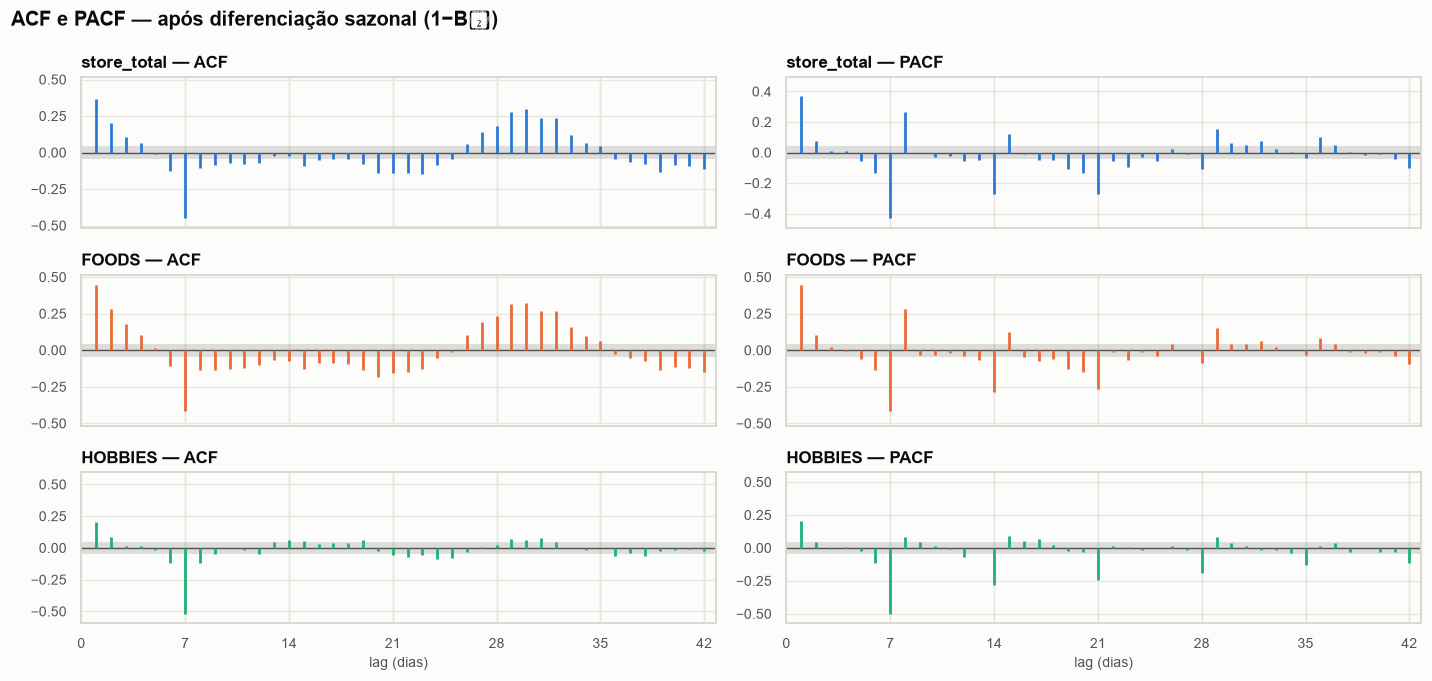

In [21]:
correlogramas(train_fit, lambda x: x.diff(M),
              "ACF e PACF — após diferenciação sazonal (1−B⁷)", "07_acf_pacf_d7.png")

/var/folders/b_/1_lgxzw979xg1l34kqfnjgfw0000gn/T/ipykernel_41340/1383855348.py:44: UserWarning: Glyph 8311 (\N{SUPERSCRIPT SEVEN}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/b_/1_lgxzw979xg1l34kqfnjgfw0000gn/T/ipykernel_41340/1383855348.py:45: UserWarning: Glyph 8311 (\N{SUPERSCRIPT SEVEN}) missing from font(s) Arial.
  fig.savefig(FIGS / nome)
/Users/sodre/Library/CloudStorage/OneDrive-FundacaoGetulioVargas-FGV/FGV - CD/6 PERÍODO/Séries Temporais/time-series-2026-2/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8311 (\N{SUPERSCRIPT SEVEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


  → figuras/08_acf_pacf_d7_d1.png


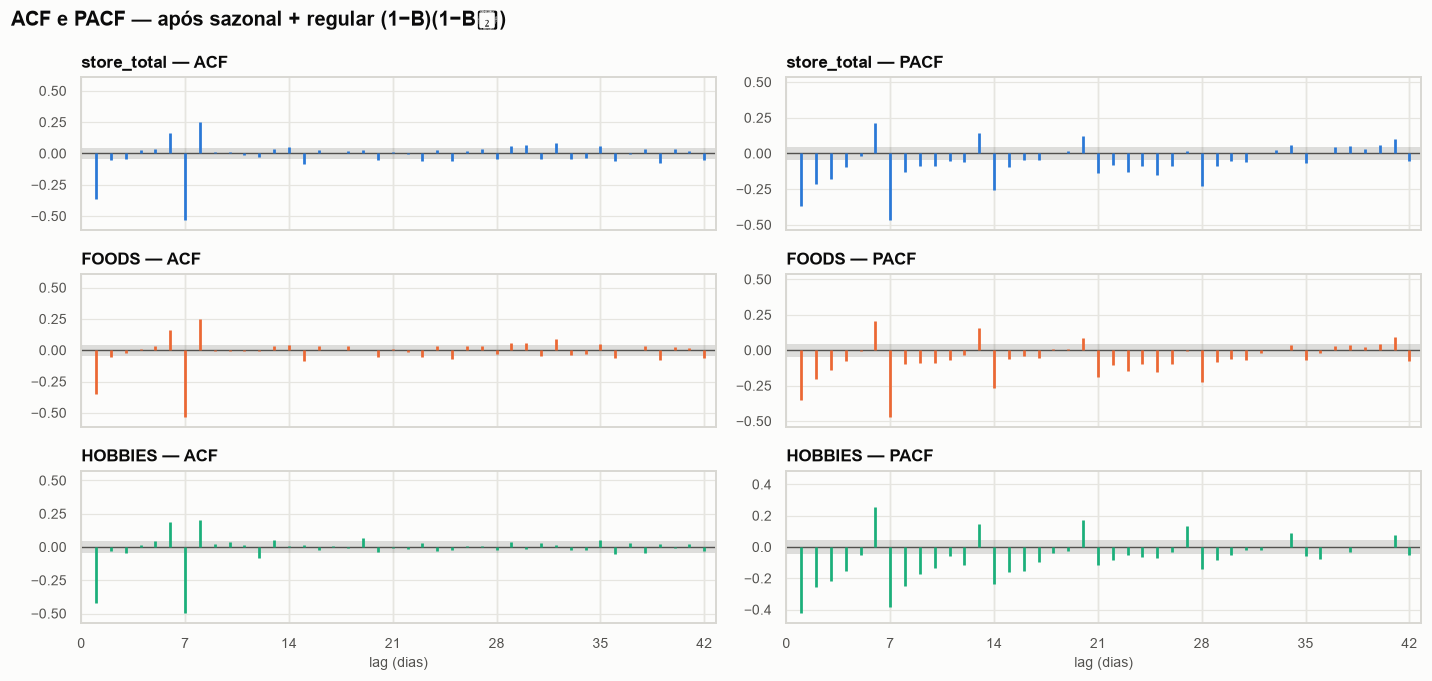

In [22]:
correlogramas(train_fit, lambda x: x.diff(M).diff(1),
              "ACF e PACF — após sazonal + regular (1−B)(1−B⁷)", "08_acf_pacf_d7_d1.png")

#### Os mesmos correlogramas em números

Ler barra por barra no gráfico é impreciso. A tabela abaixo traz os lags que
decidem a ordem. Valores com módulo abaixo de **0,045** estão dentro da banda de
confiança e devem ser lidos como zero.

In [23]:
LAGS_CHAVE = [1, 2, 3, 7, 14, 21, 28]

linhas = {}
for nome, f in versoes.items():
    for s in SERIES:
        x = f(train_fit[s]).dropna()
        a = acf(x, nlags=max(LAGS_CHAVE))
        p = pacf(x, nlags=max(LAGS_CHAVE), method="ywm")
        linhas[(nome, s, "ACF")] = {f"lag {k}": a[k] for k in LAGS_CHAVE}
        linhas[(nome, s, "PACF")] = {f"lag {k}": p[k] for k in LAGS_CHAVE}

correl = pd.DataFrame(linhas).T.round(3)
correl.index.names = ["versão", "série", "função"]
correl.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-0.6, vmax=0.6)

#### Guia de leitura

Para um $SARIMA(p,d,q)(P,D,Q)_7$:

| Onde olhar | O que decide | Regra |
|---|---|---|
| Lags 1, 2, 3 do **PACF** | `p` | corte abrupto após o lag $k$ → $p = k$ |
| Lags 1, 2, 3 do **ACF** | `q` | corte abrupto após o lag $k$ → $q = k$ |
| Lags 7, 14, 21 do **PACF** | `P` | mesma lógica, contando em múltiplos de 7 |
| Lags 7, 14, 21 do **ACF** | `Q` | mesma lógica |
| Decaimento lento no ACF | `d`, `D` | falta diferenciar |

Dois sinais clássicos:

- ACF decaindo devagar e PACF cortando no lag 1 → componente **AR**.
- ACF cortando no lag 1 e PACF decaindo → componente **MA**.
- Sobre-diferenciação aparece como um ACF fortemente negativo no lag 1
  (abaixo de −0,5), e é motivo para reduzir `d` ou `D`.

`d` e `D` ficam **fora** do grid de AIC que vem na próxima fase: o AIC não é
comparável entre modelos com diferenciação diferente, porque diferenciar muda a
própria série e o número de observações efetivas. Testes decidem `d` e `D`;
o AIC decide `p, q, P, Q`.

### 2.7 Resumo do diagnóstico

**Tendência.** `store_total` e `FOODS` sobem de ≈3000 em 2011 para ≈4500-5000 a
partir de 2013, com platô depois de 2014 (força de tendência 0,73 e 0,71).
`HOBBIES` tem tendência mais fraca e irregular (0,53), com um degrau claro no
começo de 2013: a tendência cai para ≈290 no fim de 2012 e sobe para ≈500 em
seguida.

**Sazonalidade semanal (m = 7).** Confirmada nas três séries. Em `store_total` o
índice por dia da semana vai de **82,7** (quarta) a **127,4** (domingo), uma
amplitude de 45 pontos. Sábado e domingo concentram o movimento; terça a quinta
são o vale. `HOBBIES` repete o padrão com amplitude menor (88,7 a 124,8). Mais
importante: em nível, a ACF nos lags 7, 14, 21 e 28 fica entre **0,80 e 0,84**
(`store_total`) **sem decair** — isso é não-estacionariedade sazonal, não apenas
sazonalidade.

**Outliers.** Cinco zeros, todos em 25/12, as três séries juntas: a loja fecha no
Natal. Tratados por interpolação linear apenas no pipeline do SARIMA (seção 2.2).
Não há outros faltantes nem buracos de data.

**Um terceiro ciclo, mensal.** Depois de $(1-B^7)$ a ACF volta a subir nos lags 28
a 32 (+0,18 a +0,30 em `store_total` e `FOODS`; ausente em `HOBBIES`). É
consistente com o ciclo mensal de pagamentos e do benefício SNAP, que afeta
alimentos. Um SARIMA com $m = 7$ não captura isso — fica registrado como
limitação conhecida do modelo, não como erro de ajuste.

#### O que os testes dizem sobre a diferenciação

| Evidência | Leitura |
|---|---|
| Em nível, KPSS rejeita nas três séries (p ≤ 0,01) e a ACF sazonal não decai | diferenciar |
| Após $(1-B^7)$: KPSS não rejeita (p = 0,10) e ADF rejeita raiz unitária (p < 0,001) | pelo KPSS iterativo, **d = 0** já basta |
| Após $(1-B)(1-B^7)$: ACF no lag 1 vira −0,37 / −0,35 / −0,43 | lag-1 negativo é o sinal clássico de **sobre-diferenciação** |
| Força sazonal 0,837 e 0,825 (`store_total`, `FOODS`), acima do corte de 0,64 | **D = 1** |
| Força sazonal de `HOBBIES` em 0,465, abaixo do corte | sugere D = 0 — mas a ACF em nível nos lags 7/14/21 fica em 0,51-0,55 sem decair, o que aponta D = 1 |
| Após $(1-B^7)$, a ACF de `HOBBIES` no lag 7 é −0,517 | pouco além do limite teórico de −0,5 de um MA(1) sazonal: leve indício de sobre-diferenciação |

#### O que os correlogramas sugerem para p, q, P, Q

Com $D = 1$ e $d = 0$, lendo a figura 07:

- O **PACF corta depois do lag 1** (0,368 → 0,078 → 0,009 em `store_total`) e a ACF
  decai geometricamente nos primeiros lags → componente **AR(1)**, isto é $p = 1$.
- A **ACF no lag 7 é fortemente negativa** (−0,45 / −0,41 / −0,52) e o PACF nos
  lags 7, 14, 21 decai (−0,43, −0,28, −0,27) → assinatura de **MA sazonal de ordem
  1**, isto é $P = 0$ e $Q = 1$.
- Candidato natural: $SARIMA(1,0,0)(0,1,1)_7$.

Com $d = 1$ (figura 08) a leitura muda: a ACF corta no lag 1 (−0,37) **e** no lag 7
(−0,53), com o PACF decaindo nos dois → é a assinatura do modelo *airline*,
$SARIMA(0,1,1)(0,1,1)_7$.

> **Decisão pendente.** `d` e `D` são fixados manualmente a partir desta leitura.
> O grid de AIC da próxima fase decide apenas `p`, `q`, `P` e `Q`, com `d` e `D`
> já travados.

---

Com `d` e `D` ainda abertos, a seção 3 estabelece a régua — os quatro baselines —
e a seção 4 fecha a ordem do SARIMA com testes e grid search.

## 3. Os quatro baselines

Antes de qualquer modelo, os quatro métodos simples da aula 20/08. Eles não são
formalidade: o SARIMA só se justifica se ganhar deles. Os quatro preveem os mesmos
28 dias, a partir do mesmo treino.

| Baseline | Fórmula | Ideia |
|---|---|---|
| `media` | $\hat y_{T+h} = \bar y$ | tudo é ruído em torno de um nível |
| `naive` | $\hat y_{T+h} = y_T$ | o melhor palpite de amanhã é hoje |
| `naive_sazonal` | $\hat y_{T+h} = y_{T+h-m\lceil h/m\rceil}$ | a semana se repete |
| `drift` | $\hat y_{T+h} = y_T + h\,\dfrac{y_T - y_1}{T-1}$ | naive mais a reta que liga a primeira à última observação |

Convenções do FPP3 (Hyndman & Athanasopoulos, cap. 5.2).

**Os baselines rodam no dado cru**, não no interpolado. A interpolação do Natal é
decisão do pipeline do SARIMA (seção 2.2); aplicá-la aqui mudaria a escala do MASE
e divergiria do critério de correção, que lê o `treino.csv` como está.

In [24]:
def baselines(y: pd.Series) -> dict[str, np.ndarray]:
    """As quatro previsões de referência para h = 1..H, sempre no dado cru."""
    yv = y.to_numpy(dtype=float)
    T = len(yv)
    h = np.arange(1, H + 1)
    return {
        "media": np.full(H, yv.mean()),
        "naive": np.full(H, yv[-1]),
        "naive_sazonal": yv[-M:][(h - 1) % M],
        "drift": yv[-1] + h * (yv[-1] - yv[0]) / (T - 1),
    }


# O naive sazonal só alinha se o primeiro dia da validação cair no mesmo dia da
# semana que train[-7]. Trava barata: quebraria em silêncio se o split mudasse.
assert train.index[-M].day_name() == val.index[0].day_name(), "naive sazonal desalinhado"

PREV_BASE = {s: baselines(train[s]) for s in SERIES}

print(f"treino termina  {train.index[-1]:%Y-%m-%d} ({train.index[-1].day_name()})")
print(f"validação abre  {val.index[0]:%Y-%m-%d} ({val.index[0].day_name()})\n")
for s in SERIES:
    yv = train[s].to_numpy(float)
    print(f"  {s:12} inclinação do drift: {(yv[-1] - yv[0]) / (len(yv) - 1):+7.3f} unidade/dia")

treino termina  2016-03-27 (Sunday)
validação abre  2016-03-28 (Monday)

  store_total  inclinação do drift:  +0.176 unidade/dia
  FOODS        inclinação do drift:  +0.067 unidade/dia
  HOBBIES      inclinação do drift:  -0.099 unidade/dia


In [25]:
tab_base = pd.DataFrame(
    {
        (s, modelo): {"h=1": v[0], "h=14": v[13], "h=28": v[27]}
        for s in SERIES
        for modelo, v in PREV_BASE[s].items()
    }
).T.round(1)
tab_base.index.names = ["série", "modelo"]
tab_base

h=1    h=14    h=28
série       modelo                               
store_total media          4016.1  4016.1  4016.1
            naive          4669.0  4669.0  4669.0
            naive_sazonal  4242.0  4669.0  4669.0
            drift          4669.2  4671.5  4673.9
FOODS       media          2809.6  2809.6  2809.6
            naive          3366.0  3366.0  3366.0
            naive_sazonal  2766.0  3366.0  3366.0
            drift          3366.1  3366.9  3367.9
HOBBIES     media           457.1   457.1   457.1
            naive           369.0   369.0   369.0
            naive_sazonal   532.0   369.0   369.0
            drift           368.9   367.6   366.2

`drift` e `naive` saem quase idênticos, e isso é correto. A inclinação do drift usa
só a primeira e a última observação; como as séries sobem forte de 2011 a 2013 e
depois estabilizam (seção 2.1), essa reta não enxerga a forma da tendência. Ao longo
dos 28 dias o acúmulo é de poucas unidades, invisível perto da variação diária.

O `naive_sazonal` é o baseline a bater: é o único que carrega a estrutura semanal,
que o diagnóstico mostrou ser o sinal dominante.

  → figuras/09_baselines.png


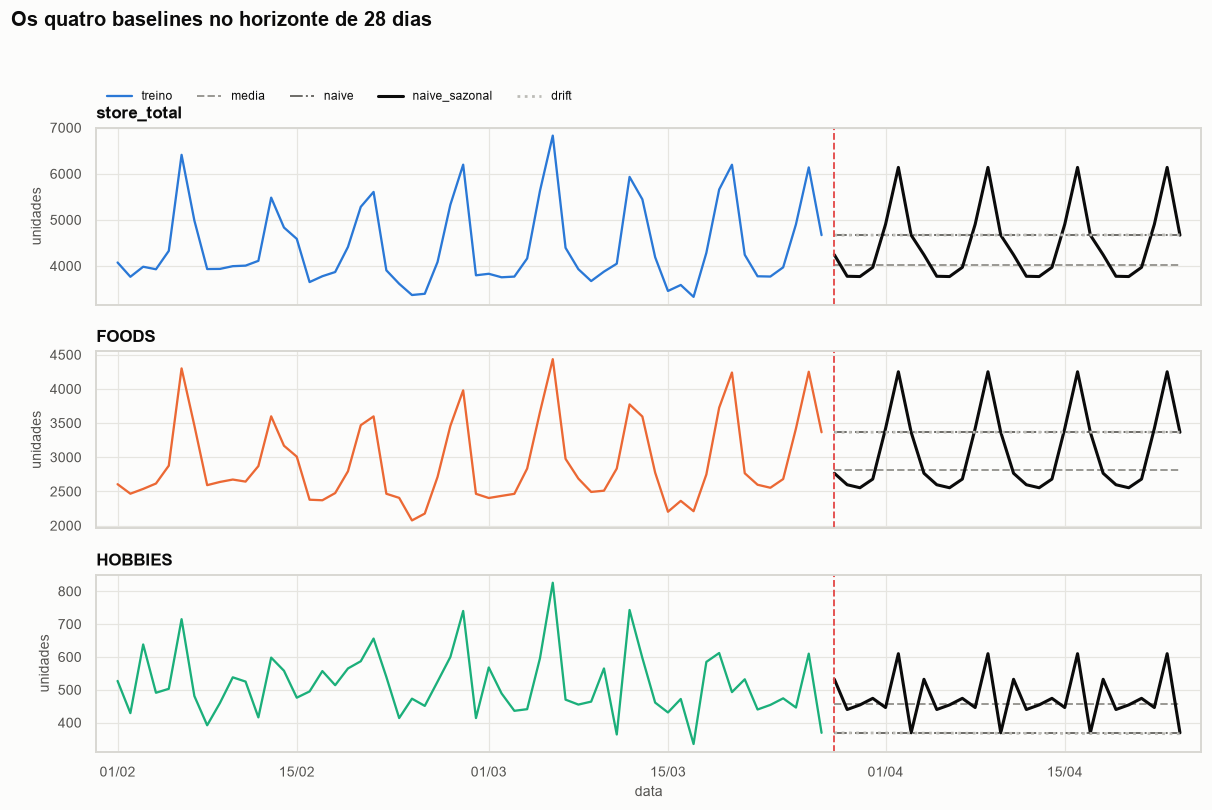

In [26]:
ESTILO = {"media": ("--", 1.3), "naive": ("-.", 1.3), "naive_sazonal": ("-", 2.0), "drift": (":", 1.8)}
CINZAS = {"media": "#9b9a95", "naive": "#6f6e6a", "naive_sazonal": TINTA, "drift": "#bcbbb6"}

fig, axes = painel(3, altura=2.4)
for ax, s in zip(axes, SERIES):
    cauda = train.loc[TREINO_FIM - pd.Timedelta(days=55) :, s]
    ax.plot(cauda.index, cauda, color=CORES[s], lw=1.5, label="treino")
    for modelo, yhat in PREV_BASE[s].items():
        ls, lw = ESTILO[modelo]
        ax.plot(val.index, yhat, ls=ls, lw=lw, color=CINZAS[modelo], label=modelo)
    ax.axvline(VAL_START, color=DESTAQUE, lw=1.2, ls="--")
    ax.set_title(s)
    ax.set_ylabel("unidades")
    ax.margins(x=0.02)
axes[0].legend(ncol=5, loc="lower left", fontsize=8, bbox_to_anchor=(0, 1.08))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[-1].set_xlabel("data")
fig.suptitle("Os quatro baselines no horizonte de 28 dias", x=0.0, ha="left",
             fontsize=13, fontweight="bold", y=1.02)
salvar(fig, "09_baselines.png")
plt.show()

## 4. Identificação da ordem do SARIMA

A seção 2 leu os correlogramas a olho e chegou a dois candidatos. Esta seção troca a
leitura visual por três procedimentos, nesta ordem:

| Passo | Decide | Como |
|---|---|---|
| 4.1 | `D` | força sazonal da STL + ACF em nível |
| 4.2 | `d` | KPSS iterativo sobre a série já sazonalmente diferenciada |
| 4.3–4.4 | `D` do `HOBBIES` | backtest de origem rolante dentro do treino |
| 4.5–4.6 | `p, q, P, Q` | grid search minimizando AICc, com `d` e `D` travados |

**Por que `d` e `D` ficam fora do grid.** O AICc é função da verossimilhança, e
diferenciar muda a série: o número de observações efetivas cai de $n$ para
$n - d - Dm$ e a verossimilhança passa a ser calculada sobre outra amostra. Comparar
AICc entre ordens de diferenciação diferentes é comparar números que não estão na
mesma escala. Por isso testes de hipótese e validação fora da amostra decidem `d` e
`D`; o AICc decide só o resto.

**Por que AICc e não AIC.** A correção de segunda ordem
$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n-k-1}$ penaliza modelos com muitos
parâmetros em amostra finita. Com $n \approx 1878$ e $k \le 11$ a diferença é
pequena, mas o AICc nunca é pior e é o padrão do FPP3.

### 4.1 `D`, a diferenciação sazonal

Critério de Wang-Smyth-Hyndman: $F_s > 0{,}64$ pede $D = 1$. A tabela da seção 2.4,
agora com a ACF em nível nos múltiplos de 7 ao lado — porque ACF sazonal que **não
decai** é o sintoma direto de raiz unitária sazonal.

In [27]:
d_sazonal = pd.DataFrame(
    {
        s: {
            "F_sazonal": tabela_forcas.loc[s, "F_sazonal"],
            "ACF(7)": acf(train_fit[s], nlags=28)[7],
            "ACF(14)": acf(train_fit[s], nlags=28)[14],
            "ACF(21)": acf(train_fit[s], nlags=28)[21],
            "ACF(28)": acf(train_fit[s], nlags=28)[28],
        }
        for s in SERIES
    }
).T.round(3)
d_sazonal["F_s > 0,64"] = np.where(d_sazonal["F_sazonal"] > 0.64, "sim → D=1", "não → ?")
d_sazonal

,F_sazonal,ACF(7),ACF(14),ACF(21),ACF(28),"F_s > 0,64"
store_total,0.837,0.836,0.816,0.803,0.835,sim → D=1
FOODS,0.825,0.801,0.764,0.756,0.810,sim → D=1
HOBBIES,0.465,0.534,0.550,0.507,0.519,não → ?


`store_total` e `FOODS` são claros: força sazonal acima de 0,82 e ACF sazonal que não
decai. **`D = 1`** nos dois.

`HOBBIES` não fecha. A força sazonal fica abaixo do corte, mas a ACF nos lags 7, 14,
21 e 28 se sustenta em torno de 0,5 sem decair — assinatura de raiz unitária sazonal.
Os dois critérios discordam, então a decisão fica **em aberto** até o backtest da
seção 4.4. Enquanto isso, carregamos as duas hipóteses em paralelo.

### 4.2 `d`, pelo KPSS iterativo

Procedimento de Hyndman-Khandakar: testar a série por KPSS; se rejeitar a hipótese
nula de estacionariedade ($p < 0{,}05$), diferenciar uma vez e testar de novo, até
não rejeitar ou chegar a $d = 2$.

Dois cuidados:

1. **Roda depois do `D`.** A diferenciação sazonal já remove boa parte da
   não-estacionariedade; aplicar o KPSS à série em nível superestima o `d` e leva à
   sobre-diferenciação que a seção 2.7 já flagrou (ACF do lag 1 em −0,37).
2. **O `D` do `HOBBIES` está em aberto**, então rodamos o procedimento nas duas
   hipóteses e deixamos o backtest escolher.

In [28]:
def d_por_kpss(y, *, D: int, m: int = M, alpha: float = 0.05, d_max: int = 2):
    """KPSS iterativo sobre a série já diferenciada D vezes no período sazonal."""
    x = np.asarray(y, dtype=float)
    for _ in range(D):
        x = x[m:] - x[:-m]

    d, trilha = 0, []
    while True:
        stat, p, lags = kpss_teste(x)
        _, p_adf = adf_teste(x)
        rejeita = p < alpha
        trilha.append({
            "KPSS stat": stat,
            "KPSS p": p,
            "lags": lags,
            "ADF p": p_adf,
            "decisão": "diferencia" if rejeita and d < d_max else "para",
        })
        if not rejeita or d == d_max:
            return d, pd.DataFrame(trilha).assign(d=range(len(trilha)))
        x = np.diff(x)
        d += 1


# store_total e FOODS já têm D=1 fechado; HOBBIES carrega as duas hipóteses.
HIPOTESES = {"store_total": (1,), "FOODS": (1,), "HOBBIES": (1, 0)}

d_escolhido, _trilhas = {}, []
for s, Ds in HIPOTESES.items():
    for D in Ds:
        d, tr = d_por_kpss(train_fit[s], D=D)
        d_escolhido[(s, D)] = d
        _trilhas.append(tr.assign(série=s, D=D))

trilha_kpss = (
    pd.concat(_trilhas, ignore_index=True)
    .set_index(["série", "D", "d"])[["KPSS stat", "KPSS p", "lags", "ADF p", "decisão"]]
    .round(4)
)
trilha_kpss

KPSS stat  KPSS p  lags   ADF p     decisão
série       D d                                             
store_total 1 0     0.0093    0.10    14  0.0000        para
FOODS       1 0     0.0103    0.10    17  0.0000        para
HOBBIES     1 0     0.0075    0.10     8  0.0000        para
            0 0     5.0515    0.01    21  0.0369  diferencia
              1     0.0393    0.10    63  0.0000        para

In [29]:
print("d escolhido pelo KPSS iterativo:\n")
for (s, D), d in d_escolhido.items():
    marca = "" if len(HIPOTESES[s]) == 1 else "   (hipótese)"
    print(f"  {s:12} D={D} → d={d}{marca}")

d escolhido pelo KPSS iterativo:

  store_total  D=1 → d=0
  FOODS        D=1 → d=0
  HOBBIES      D=1 → d=0   (hipótese)
  HOBBIES      D=0 → d=1   (hipótese)


Com `D = 1` o loop para na primeira iteração nas três séries: o KPSS não rejeita
estacionariedade, e o ADF rejeita raiz unitária com folga. **`d = 0`**. Isso fecha
com o que a seção 2.7 já tinha visto — aplicar também $(1-B)$ levava a ACF do lag 1
para perto de −0,4, o sinal clássico de sobre-diferenciação.

Na hipótese `D = 0` do `HOBBIES`, o KPSS rejeita em nível e o procedimento pede
`d = 1`. As duas especificações concorrentes ficam então:

- $(d, D) = (0, 1)$ — diferenciação sazonal
- $(d, D) = (1, 0)$ — diferenciação regular

Quem decide é o backtest, não o AICc.

### 4.3 Grid search de AICc

Com `d` e `D` travados, sobram quatro ordens para escolher: $p, q \in \{0,1,2,3\}$ e
$P, Q \in \{0,1,2\}$ — 144 combinações por especificação.

Três detalhes de implementação que mudam o resultado, não só a velocidade:

**1. `maxiter=200`, não o default.** O default de `.fit()` é 50 iterações, com o qual
os modelos de ordem maior não convergem. O AICc de um fit não convergido é ruído, e
rankear por ele é rankear ruído: medimos 27787,6 (não convergido) contra 27756,5
(convergido) para a mesma ordem.

**2. Guarda contra ótimo degenerado.** Em parte dos ajustes o filtro de Kalman
colapsa e devolve `llf == 0.0` exato — o AICc vira só a penalidade, fica
artificialmente baixo e o `argmin` cru escolhe esse modelo. A previsão resultante é
identicamente zero. Pior: `converged=True` e `enforce_stationarity=True` **não**
pegam o caso. Exigimos `llf < 0` **e** convergência, e conferimos a plausibilidade da
previsão do vencedor na seção 4.7.

**3. Uma thread de BLAS.** Já fixada na célula de setup. Sem isso o L-BFGS percorre
trajetórias diferentes entre execuções e o grid deixa de ser reprodutível.

O paralelismo usa processos com contexto `fork`: o padrão do Python 3.14 no Linux é
`forkserver`, que reimporta o `__main__` e quebra dentro de um notebook.

In [30]:
def _ok(r) -> bool:
    """Um fit é utilizável? `llf == 0.0` exato = filtro de Kalman degenerado."""
    return bool(
        np.isfinite(r.llf)
        and r.llf < 0
        and np.isfinite(r.aicc)
        and r.mle_retvals["converged"]
    )


def ajustar(serie: str, order, seasonal_order, dados=None):
    """Um SARIMAX com os argumentos que o notebook usa em todo lugar."""
    y = train_fit[serie] if dados is None else dados
    return SARIMAX(
        y,
        order=order,
        seasonal_order=seasonal_order,
        trend=None,  # a média de (1−B⁷)y não é significativa; ver 4.3
        enforce_stationarity=True,
        enforce_invertibility=True,
    ).fit(disp=False, method="lbfgs", maxiter=MAXITER)


def um_fit(arg):
    """Worker do grid. Roda em processo filho (fork), herda train_fit."""
    serie, p, d, q, P, D, Q = arg
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", EstimationWarning)
    base = {"série": serie, "p": p, "d": d, "q": q, "P": P, "D": D, "Q": Q}
    t0 = time.perf_counter()
    try:
        # o filho herda o limite pelo fork, mas repetir aqui mantém o worker
        # correto mesmo se o contexto de multiprocessing mudar
        with threadpool_limits(limits=1):
            r = ajustar(serie, (p, d, q), (P, D, Q, M))
        return base | {
            "aicc": float(r.aicc),
            "bic": float(r.bic),
            "llf": float(r.llf),
            "convergiu": bool(r.mle_retvals["converged"]),
            "n_par": len(r.params) - 1,
            "valido": _ok(r),
            "erro": None,
            "segs": time.perf_counter() - t0,
        }
    except Exception as e:  # LinAlgError acontece de fato em ordens altas
        return base | {
            "aicc": np.nan, "bic": np.nan, "llf": np.nan, "convergiu": False,
            "n_par": np.nan, "valido": False, "erro": type(e).__name__,
            "segs": time.perf_counter() - t0,
        }


def rodar_grid(jobs, rotulo: str) -> pd.DataFrame:
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=N_JOBS, mp_context=mp.get_context("fork")) as ex:
        res = pd.DataFrame(list(ex.map(um_fit, jobs)))
    dt = time.perf_counter() - t0
    print(f"  {rotulo}: {len(jobs)} fits em {dt:.0f}s "
          f"({res['valido'].sum()} válidos, {(~res['convergiu']).sum()} não convergiram, "
          f"{res['erro'].notna().sum()} exceções)")
    return res


def jobs_de(serie: str, d: int, D: int):
    return [
        (serie, p, d, q, P, D, Q)
        for p, q, P, Q in itertools.product(
            range(P_MAX + 1), range(Q_MAX + 1), range(PS_MAX + 1), range(QS_MAX + 1)
        )
    ]


print(f"{len(jobs_de('store_total', 0, 1))} combinações por especificação")

144 combinações por especificação


#### O `trend`

`trend=None` não é escolha por omissão: a média da série sazonalmente diferenciada é
indistinguível de zero nas três séries, então um intercepto não se justifica.

In [31]:
teste_trend = pd.DataFrame(
    {
        s: {
            "média de (1−B⁷)y": (dy := train_fit[s].diff(M).dropna()).mean(),
            "erro padrão": dy.std() / np.sqrt(len(dy)),
            "t": dy.mean() / (dy.std() / np.sqrt(len(dy))),
        }
        for s in SERIES
    }
).T.round(3)
teste_trend["significativo a 5%"] = np.where(teste_trend["t"].abs() > 1.96, "sim", "não")
teste_trend

,média de (1−B⁷)y,erro padrão,t,significativo a 5%
store_total,4.129,12.719,0.325,não
FOODS,2.057,9.947,0.207,não
HOBBIES,0.204,2.706,0.075,não


#### Grid do `HOBBIES`, nas duas hipóteses de `D`

Rodamos o grid separadamente para cada especificação. Dentro de cada uma o AICc é
válido; **entre** elas, não. É isso que torna a comparação da seção 4.4 justa: o AICc
escolhe o melhor modelo de cada família, e o backtest compara as duas famílias por
erro fora da amostra.

In [33]:
grids = {}
print("grid do HOBBIES (2 × 144 fits)")
grids[("HOBBIES", 0, 1)] = rodar_grid(jobs_de("HOBBIES", 0, 1), "HOBBIES d=0 D=1")
grids[("HOBBIES", 1, 0)] = rodar_grid(jobs_de("HOBBIES", 1, 0), "HOBBIES d=1 D=0")

grid do HOBBIES (2 × 144 fits)


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

In [ ]:
def melhor(df: pd.DataFrame) -> pd.Series:
    """Menor AICc entre os fits válidos. Nunca o argmin cru."""
    validos = df[df["valido"]]
    assert not validos.empty, "nenhum fit válido no grid"
    return validos.loc[validos["aicc"].idxmin()]


def rotulo(r) -> str:
    return f"SARIMA({r.p:.0f},{r.d:.0f},{r.q:.0f})({r.P:.0f},{r.D:.0f},{r.Q:.0f})[{M}]"


cand_D = {D: melhor(grids[("HOBBIES", d, D)]) for d, D in [(0, 1), (1, 0)]}
pd.DataFrame(
    {f"D={D}": {"ordem": rotulo(r), "AICc": round(r.aicc, 2), "llf": round(r.llf, 1),
                "n_par": int(r.n_par)}
     for D, r in cand_D.items()}
).T

### 4.4 Backtest de origem rolante — quem decide o `D`

O AICc não compara as duas famílias. O erro fora da amostra compara.

**Desenho.** Janela **expansiva** (a série tem 1885 dias e tendência leve; janela
deslizante jogaria fora metade do histórico), 12 origens **não sobrepostas** para que
nenhum dia entre duas vezes no erro agregado, horizonte 28 em cada origem — o mesmo
da Task — e refit completo a cada origem.

**Todas as origens ficam dentro do treino.** A última termina exatamente em
2016-03-27. A validação não é tocada.

Como na entrega, o ajuste usa `train_fit` (interpolado) e o erro é medido contra
`train` cru. A escala do MASE é a escala global do treino cru, não recalculada por
origem — assim o número é comparável ao da tabela final da seção 6.

**Regra de desempate, declarada antes de ver o resultado:** se a diferença de MAE
ficar abaixo de 5%, fica `D = 1`, por coerência com as outras duas séries e porque é
o tratamento padrão de sazonalidade semanal persistente.

In [ ]:
def um_fold(arg):
    """Uma origem do backtest: ajusta até `corte`, prevê H dias, erra contra o cru."""
    serie, order, sorder, corte = arg
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", EstimationWarning)
    try:
        with threadpool_limits(limits=1):
            r = ajustar(serie, order, sorder, dados=train_fit[serie].iloc[:corte])
            yhat = r.get_forecast(steps=H).predicted_mean.to_numpy(dtype=float)
    except Exception:
        return corte, np.full(H, np.nan)
    y = train[serie].iloc[corte : corte + H].to_numpy(dtype=float)
    return corte, yhat - y


N_TREINO = len(train_fit)
CORTES = [N_TREINO - H * k for k in range(K_BT, 0, -1)]

print(f"{K_BT} origens, horizonte {H}, blocos não sobrepostos")
print(f"primeira origem prevê a partir de {train.index[CORTES[0]]:%Y-%m-%d}")
print(f"última origem  prevê a partir de {train.index[CORTES[-1]]:%Y-%m-%d} "
      f"(termina em {train.index[CORTES[-1] + H - 1]:%Y-%m-%d})")
assert CORTES[-1] + H == N_TREINO, "o backtest passaria do fim do treino"

In [ ]:
ESCALA_MASE = {
    s: float(np.abs((_y := train[s].to_numpy(float))[M:] - _y[:-M]).mean()) for s in SERIES
}

tarefas_bt = [
    ("HOBBIES", (int(r.p), int(r.d), int(r.q)), (int(r.P), int(r.D), int(r.Q), M), corte)
    for D, r in cand_D.items()
    for corte in CORTES
]

t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=N_JOBS, mp_context=mp.get_context("fork")) as ex:
    saida = list(ex.map(um_fold, tarefas_bt))
print(f"{len(tarefas_bt)} fits de backtest em {time.perf_counter() - t0:.0f}s")

# tarefas_bt foi montado D a D, então cada bloco de K_BT saídas é um D
erros_bt = {
    D: np.vstack([saida[i * K_BT + j][1] for j in range(K_BT)])
    for i, D in enumerate(cand_D)
}
assert all(np.isfinite(v).all() for v in erros_bt.values()), "fold do backtest falhou"

In [ ]:
mae_origem = pd.DataFrame(
    {f"D={D}": np.abs(e).mean(axis=1) for D, e in erros_bt.items()},
    index=[f"{train.index[c]:%Y-%m-%d}" for c in CORTES],
)
mae_origem.index.name = "origem"
mae_origem["Δ (D=1 − D=0)"] = mae_origem["D=1"] - mae_origem["D=0"]

resumo_bt = pd.DataFrame({
    f"D={D}": {
        "MAE agregado": np.abs(e).mean(),
        "MASE agregado": np.abs(e).mean() / ESCALA_MASE["HOBBIES"],
        "RMSE agregado": np.sqrt((e ** 2).mean()),
        "origens em que ganha": int((mae_origem[f"D={D}"] == mae_origem[["D=1", "D=0"]].min(axis=1)).sum()),
    }
    for D, e in erros_bt.items()
}).T.round(4)
display(resumo_bt)
mae_origem.round(2)

In [ ]:
mae1, mae0 = resumo_bt.loc["D=1", "MAE agregado"], resumo_bt.loc["D=0", "MAE agregado"]
margem = (mae0 - mae1) / mae0
delta = mae_origem["Δ (D=1 − D=0)"]
t_pareado = delta.mean() / (delta.std(ddof=1) / np.sqrt(len(delta)))

D_HOBBIES = 1 if (margem > -0.05) else 0
print(f"MAE do backtest   D=1: {mae1:.3f}   D=0: {mae0:.3f}")
print(f"margem a favor de D=1: {margem:+.2%}")
print(f"t pareado sobre as {len(delta)} origens: {t_pareado:.2f} "
      f"({'significativo' if abs(t_pareado) > 2.2 else 'não significativo'} a 5%)")
print(f"\n→ D = {D_HOBBIES} para HOBBIES")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4), width_ratios=[2.2, 1])
x = np.arange(len(CORTES))
larg = 0.38
for i, (D, cor) in enumerate([(1, CORES["HOBBIES"]), (0, "#9b9a95")]):
    axes[0].bar(x + (i - 0.5) * larg, mae_origem[f"D={D}"], larg, label=f"D={D}", color=cor)
axes[0].set_xticks(x, [f"{train.index[c]:%b/%y}" for c in CORTES], rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE por origem do backtest")
axes[0].legend(ncol=2, fontsize=9)

axes[1].axhline(0, color=TINTA_2, lw=1)
axes[1].bar(x, delta, color=np.where(delta < 0, CORES["HOBBIES"], DESTAQUE))
axes[1].set_xticks([])
axes[1].set_xlabel("origem")
axes[1].set_ylabel("Δ MAE")
axes[1].set_title("D=1 − D=0  (negativo: D=1 ganha)")
fig.suptitle("Backtest de origem rolante — HOBBIES", x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "10_backtest_hobbies.png")
plt.show()

#### O que o backtest diz

| | `D = 1` | `D = 0` |
|---|---|---|
| ordem vencedora do AICc na família | SARIMA(2,0,2)(0,1,1)₇ | SARIMA(1,1,2)(1,0,1)₇ |
| MAE agregado, 12 origens | **63,61** | 65,32 |
| MASE agregado | **0,697** | 0,715 |
| origens em que ganha | 7 | 5 |

`D = 1` ganha por **2,6%** de MAE, com $t$ pareado de **−1,19** sobre as 12 origens:
**não significativo** a 5%. Em 5 das 12 origens o `D = 0` é melhor, e a maior
diferença individual (−10,2 em agosto/2015) é da ordem do desvio entre origens.

A regra declarada antes do teste resolve o empate: margem abaixo de 5% → fica
`D = 1`, por coerência com `store_total` e `FOODS` e porque a ACF em nível da seção
4.1 aponta raiz unitária sazonal. O backtest não deu uma resposta forte; deu uma
resposta compatível, e registrar isso é mais honesto do que apresentar 2,6% como
evidência decisiva.

**Por que a comparação é justa.** Cada `D` entrou representado pelo **seu** melhor
modelo segundo o AICc, não por uma ordem arbitrária. Comparar um `D = 1` bem
especificado contra um `D = 0` mal especificado produziria uma vitória falsa — num
teste exploratório, usar `(1,1,0)(1,0,1)₇` para o `D = 0` levou o MAE a 97, o que
"decidiria" a favor de `D = 1` por uma goleada sem significado.

### 4.5 Grid de `store_total` e `FOODS`

Com o `D` do `HOBBIES` resolvido, faltam as duas séries em que `d = 0` e `D = 1` já
estavam fechados desde 4.1 e 4.2.

In [ ]:
ESPEC = {s: (d_escolhido[(s, 1)], 1) for s in ("store_total", "FOODS")}
ESPEC["HOBBIES"] = (d_escolhido[("HOBBIES", D_HOBBIES)], D_HOBBIES)
print("especificação travada (d, D):", {s: ESPEC[s] for s in SERIES})

print("\ngrid de store_total e FOODS (2 × 144 fits)")
for s in ("store_total", "FOODS"):
    d, D = ESPEC[s]
    grids[(s, d, D)] = rodar_grid(jobs_de(s, d, D), f"{s} d={d} D={D}")

### 4.6 Os vencedores, e os fits que a guarda descartou

In [ ]:
GRID = {s: grids[(s, *ESPEC[s])] for s in SERIES}

top10 = pd.concat(
    [
        g.sort_values("aicc")
        .head(10)
        .assign(ordem=lambda df: [rotulo(r) for r in df.itertuples()])
        .set_index(["série", "ordem"])[["aicc", "llf", "n_par", "convergiu", "valido"]]
        for g in GRID.values()
    ]
).round(2)
top10

In [ ]:
descartados = pd.concat([g[~g["valido"]] for g in GRID.values()])
descartados = descartados.assign(
    ordem=[rotulo(r) for r in descartados.itertuples()],
    motivo=np.select(
        [descartados["erro"].notna(), descartados["llf"] == 0.0, ~descartados["convergiu"]],
        ["exceção", "llf = 0 (Kalman degenerado)", "não convergiu"],
        default="outro",
    ),
)
print(f"{len(descartados)} de {sum(len(g) for g in GRID.values())} fits descartados pela guarda\n")
degen = descartados[descartados["motivo"].str.startswith("llf")]
if len(degen):
    print("Os degenerados teriam AICc MENOR que o vencedor legítimo:")
    display(
        degen.set_index(["série", "ordem"])[["aicc", "llf", "convergiu", "motivo"]].round(2)
    )
descartados.groupby(["série", "motivo"], observed=True).size().rename("fits").to_frame()

In [ ]:
VENCEDOR = {s: melhor(GRID[s]) for s in SERIES}
CORRELOGRAMA = (1, 0, 0, 0, 1, 1)  # o candidato lido a olho na seção 2.7

comparacao_ordem = []
for s in SERIES:
    v = VENCEDOR[s]
    g = GRID[s]
    p0, d0, q0, P0, D0, Q0 = CORRELOGRAMA
    linha_vis = g[(g.p == p0) & (g.d == ESPEC[s][0]) & (g.q == q0)
                  & (g.P == P0) & (g.D == ESPEC[s][1]) & (g.Q == Q0)]
    aicc_vis = float(linha_vis["aicc"].iloc[0]) if len(linha_vis) else np.nan
    comparacao_ordem.append({
        "série": s,
        "grid (AICc)": rotulo(v),
        "AICc grid": v.aicc,
        "correlograma (2.7)": f"SARIMA(1,{ESPEC[s][0]},0)(0,{ESPEC[s][1]},1)[{M}]",
        "AICc correlograma": aicc_vis,
        "ΔAICc": aicc_vis - v.aicc,
    })
pd.DataFrame(comparacao_ordem).set_index("série").round(2)

#### Leitura

**A guarda não é zelo excessivo.** Dos 432 ajustes, 15 foram descartados, e três
deles — todos em `store_total` — são o caso perigoso: `llf = 0,0` exato, filtro de
Kalman colapsado, AICc de **14,06** e **16,08** contra 27721,50 do vencedor
legítimo. Um `argmin(aicc)` cru escolheria `SARIMA(3,0,2)(0,1,1)₇`, cuja previsão é
**zero nos 28 dias**. Note que esse ajuste reporta `convergiu = True`: o critério de
convergência do L-BFGS sozinho não o pega, e `enforce_stationarity=True` também não.

As outras 12 exclusões são rotina: 10 fits que esgotaram as iterações e 2 que
levantaram `LinAlgError` em ordens altas.

#### Grid contra correlograma

| série | grid (AICc) | correlograma (2.7) | ΔAICc |
|---|---|---|---|
| `store_total` | SARIMA(3,0,3)(1,1,1)₇ | SARIMA(1,0,0)(0,1,1)₇ | 52,5 |
| `FOODS` | SARIMA(2,0,2)(1,1,2)₇ | SARIMA(1,0,0)(0,1,1)₇ | 69,6 |
| `HOBBIES` | SARIMA(2,0,2)(0,1,1)₇ | SARIMA(1,0,0)(0,1,1)₇ | 77,7 |

A leitura visual da seção 2.7 acertou a **estrutura sazonal** — `(0,1,1)` aparece no
vencedor do `HOBBIES` e o componente sazonal é de ordem baixa nas três — e
subestimou a **dinâmica regular**. O PACF cortando no lag 1 sugeria $p = 1$; o grid
prefere $p = 2$ ou $3$ com termos MA junto. ΔAICc acima de 50 é uma diferença
grande: pela regra usual, Δ > 10 já descarta o modelo pior.

Isso é um resultado sobre o método, não sobre a série. Correlograma identifica
família; critério de informação afina a ordem dentro dela.

### 4.7 Refit dos vencedores e checagem de sanidade

O refit roda no processo principal, para guardar o objeto de resultado. Os asserts
aqui são a segunda linha de defesa contra o ótimo degenerado: mesmo passando pela
guarda de `llf`, uma previsão fora de qualquer escala plausível derruba a célula.

In [ ]:
MODELOS = {}
for s in SERIES:
    v = VENCEDOR[s]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        res = ajustar(s, (int(v.p), int(v.d), int(v.q)), (int(v.P), int(v.D), int(v.Q), M))
    fc = res.get_forecast(steps=H).predicted_mean
    mu = float(train[s].mean())

    assert _ok(res), f"{s}: refit não reproduziu um fit válido"
    assert np.isfinite(fc).all(), f"{s}: previsão com NaN ou inf"
    assert 0.2 * mu < fc.min() and fc.max() < 5 * mu, (
        f"{s}: previsão implausível {fc.min():.0f}–{fc.max():.0f} (média do treino {mu:.0f})"
    )
    assert fc.index.equals(val.index), f"{s}: previsão fora do horizonte de validação"
    MODELOS[s] = res
    print(f"{s:12} {rotulo(v):26} AICc {res.aicc:9.2f}  σ²={res.params['sigma2']:.0f}  "
          f"previsão {fc.min():.0f}–{fc.max():.0f}")

In [ ]:
pd.concat(
    {s: MODELOS[s].params.round(4) for s in SERIES}, axis=1
).rename_axis("parâmetro").rename(columns=lambda c: f"{c}\n{rotulo(VENCEDOR[c])}")

### 4.8 Resíduos

Se a ordem está certa, o resíduo não guarda autocorrelação. O teste de Ljung-Box
checa isso em bloco, nos lags que importam aqui (1 semana a 4 semanas).

**Corte de burn-in.** Os primeiros `loglikelihood_burn` resíduos são artefato da
inicialização difusa do filtro — o primeiro é literalmente a própria observação.
Incluí-los infla o desvio dos resíduos em mais de 10% e contamina o teste.

In [ ]:
lb_linhas = []
for s in SERIES:
    res = MODELOS[s]
    b = int(res.loglikelihood_burn) + int(getattr(res, "nobs_diffuse", 0) or 0)
    r = res.resid.iloc[b:]
    lb = acorr_ljungbox(r, lags=[M, 2 * M, 3 * M, 4 * M], model_df=len(res.params) - 1)
    for lag, linha in lb.iterrows():
        lb_linhas.append({"série": s, "lag": lag, "Q": linha["lb_stat"], "p": linha["lb_pvalue"]})

ljung = pd.DataFrame(lb_linhas).pivot(index="lag", columns="série", values="p").round(4)
ljung = ljung[list(SERIES)]
print("p-valor do Ljung-Box (H₀: resíduos sem autocorrelação; p > 0,05 é o que queremos)\n")
ljung

#### Leitura — e uma limitação que não dá para esconder

| lag | `store_total` | `FOODS` | `HOBBIES` |
|---|---|---|---|
| 7 | — | — | 0,460 |
| 14 | **0,000** | **0,000** | 0,117 |
| 21 | **0,000** | **0,000** | 0,300 |
| 28 | **0,000** | **0,000** | 0,080 |

**`HOBBIES` passa:** nenhum p-valor abaixo de 0,05, resíduo compatível com ruído
branco em todos os horizontes testados.

**`store_total` e `FOODS` não passam.** O Ljung-Box rejeita com folga nos lags 14, 21
e 28. Há estrutura que o modelo não capturou, e é exatamente a que a seção 2.7 já
tinha identificado: o ciclo de ~28-32 dias compatível com o calendário de pagamentos
e do benefício SNAP, que afeta alimentos. Um SARIMA com $m = 7$ não tem como
representar um segundo período sazonal.

Duas consequências práticas, que registramos em vez de omitir:

1. Os **intervalos de previsão** destas duas séries são otimistas — a variância dos
   resíduos subestima a incerteza real quando sobra autocorrelação.
2. A **previsão pontual** continua útil: o SARIMA bate os quatro baselines com
   margem larga (seção 6). Resíduo autocorrelacionado significa que daria para
   fazer melhor, não que o modelo esteja errado.

Tratar isso exigiria sazonalidade múltipla (termos de Fourier com $m = 7$ e
$m \approx 30{,}4$, ou TBATS) ou covariáveis de calendário — ambos fora do escopo
desta Task, que pede explicitamente SARIMA sem regressor.

O traço `—` no lag 7 não é falha: com `model_df` igual a 8 nessas duas séries, não
sobram graus de liberdade para o teste nesse lag.

In [ ]:
for i, s in enumerate(SERIES, start=11):
    res = MODELOS[s]
    b = int(res.loglikelihood_burn) + int(getattr(res, "nobs_diffuse", 0) or 0)
    fig = plt.figure(figsize=(11, 5.6))
    res.plot_diagnostics(fig=fig, lags=28)
    fig.suptitle(f"Diagnóstico dos resíduos — {s}  ·  {rotulo(VENCEDOR[s])}",
                 x=0.0, ha="left", fontsize=12, fontweight="bold")
    salvar(fig, f"{i}_residuos_{s}.png")
    plt.show()